# **Beyond the Ticket: Building an AI Strategy for Customer Support**

# Using Analytics, Machine Learning, and NLP to Identify High-Impact Automation Opportunities


Tools Used:
Python
SQL
Power BI
Machine Learning
Natural Language Processing (NLP)

# **Executive Summary**

Customer support is one of the largest operational expenses for modern e-commerce companies. While Generative AI has the potential to reduce costs and improve customer experience, not every customer interaction should be automated. Investing in the wrong workflows can lead to poor customer satisfaction, increased escalations, and wasted resources.

This project analyzes more than 80,000 customer support interactions from Flipkart to identify where AI can create the greatest operational value. Rather than treating AI as a universal solution, the analysis focuses on distinguishing between repetitive, high-volume interactions that are suitable for automation and complex cases that continue to require human expertise.

Using SQL, Python, machine learning, natural language processing, and business analytics, the project evaluates customer support performance, discovers hidden complaint patterns, predicts customer satisfaction, and develops an AI Automation Readiness framework. The final outcome is a set of data-driven recommendations that help prioritize AI investments based on expected business impact, customer experience, and operational efficiency.

# **1. Business Problem**

# Background

Customer support teams process thousands of interactions every day, ranging from simple status inquiries to complex disputes requiring human judgment. As support volumes continue to grow, organizations face increasing pressure to reduce operating costs while maintaining high levels of customer satisfaction.
Recent advances in Generative AI have created new opportunities to automate customer support. However, automating every interaction is neither practical nor desirable. Some issues are repetitive and rule-based, while others involve ambiguity, negotiation, or emotional context that still benefit from human intervention.
The challenge is therefore not whether to invest in AI, but where those investments are likely to generate the greatest business value.

# Business Objective

The objective of this project is to identify which customer support workflows should be prioritized for AI-assisted automation by analyzing historical customer interactions, support performance, and complaint characteristics.
The analysis aims to answer the following business questions:
Which customer support workflows generate the highest operational burden?
Which complaints are repetitive and suitable for automation?
Which interactions remain dependent on human expertise?
What factors are most strongly associated with poor customer satisfaction?
Where should Flipkart invest first to maximize the return on AI adoption?

# **2. Project Methodology**

This project follows a structured analytics workflow designed to simulate a real-world AI strategy engagement.
The analysis consists of six stages:
Assess the quality and reliability of the customer support data.
Engineer business-focused features that capture complaint complexity, urgency, and automation potential.
Analyze customers, agents, and support workflows to identify operational bottlenecks.
Apply natural language processing to discover complaint themes beyond predefined categories.
Build machine learning models to understand the drivers of customer satisfaction.
Develop an AI Automation Readiness framework and recommend where Flipkart should prioritize future AI investments.

In [1]:
# ==========================
# Data Manipulation
# ==========================
import pandas as pd
import numpy as np

# ==========================
# Data Visualization
# ==========================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# Statistical Analysis
# ==========================
from scipy import stats

# ==========================
# Machine Learning
# ==========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from sklearn.ensemble import RandomForestClassifier

# ==========================
# Natural Language Processing
# ==========================
import re
from collections import Counter

# ==========================
# Notebook Settings
# ==========================
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

plt.style.use('ggplot')

In [2]:
# Load dataset
df = pd.read_csv("Customer_support_data.csv")

# Display basic information
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

# Preview the data
df.head()

Rows: 85,907
Columns: 20


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01-08-2023 11:13,01-08-2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01-08-2023 12:52,01-08-2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01-08-2023 20:16,01-08-2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01-08-2023 20:56,01-08-2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01-08-2023 10:30,01-08-2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [3]:
# Display data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [4]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Item_price,17206.0,5660.774846,12825.728411,0.0,392.0,979.0,2699.75,164999.0
connected_handling_time,242.0,462.400826,246.295037,0.0,293.0,427.0,592.25,1986.0
CSAT Score,85907.0,4.242157,1.378903,1.0,4.0,5.0,5.00,5.0


In [5]:
# Summary statistics for categorical columns
df.describe(include='object').T

,count,unique,top,freq
Unique id,85907,85907,07c7a878-0d5a-42e0-97ef-de59abec0238,1
channel_name,85907,3,Inbound,68142
category,85907,12,Returns,44097
Sub-category,85907,57,Reverse Pickup Enquiry,22389
Customer Remarks,28742,18231,Good,1390
Order_id,67675,67675,3230db30-f8da-4c44-8636-ec76d1d3d4f3,1
order_date_time,17214,13766,09-08-2023 11:55,7
Issue_reported at,85907,30923,13-08-2023 10:40,13
issue_responded,85907,30262,28-08-2023 00:00,3378
Survey_response_Date,85907,31,28-Aug-23,3452


The dataset contains customer support interactions with a combination of operational, customer, and agent-related information. Initial inspection shows a mix of numerical, categorical, and text fields, providing sufficient information to analyze support workflows, customer satisfaction, and AI automation opportunities. Further data quality assessment is required to identify missing values, inconsistencies, and potential preprocessing needs before analysis.

In [6]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 85,907
Number of columns: 20


In [7]:
missing = (
    df.isnull()
      .sum()
      .to_frame("Missing Values")
)

missing["Missing %"] = (
    missing["Missing Values"] / len(df) * 100
).round(2)

missing = missing.sort_values(
    "Missing %",
    ascending=False
)

missing

,Missing Values,Missing %
connected_handling_time,85665,99.72
Customer_City,68828,80.12
Product_category,68711,79.98
Item_price,68701,79.97
order_date_time,68693,79.96
Customer Remarks,57165,66.54
Order_id,18232,21.22
Unique id,0,0.00
Sub-category,0,0.00
category,0,0.00


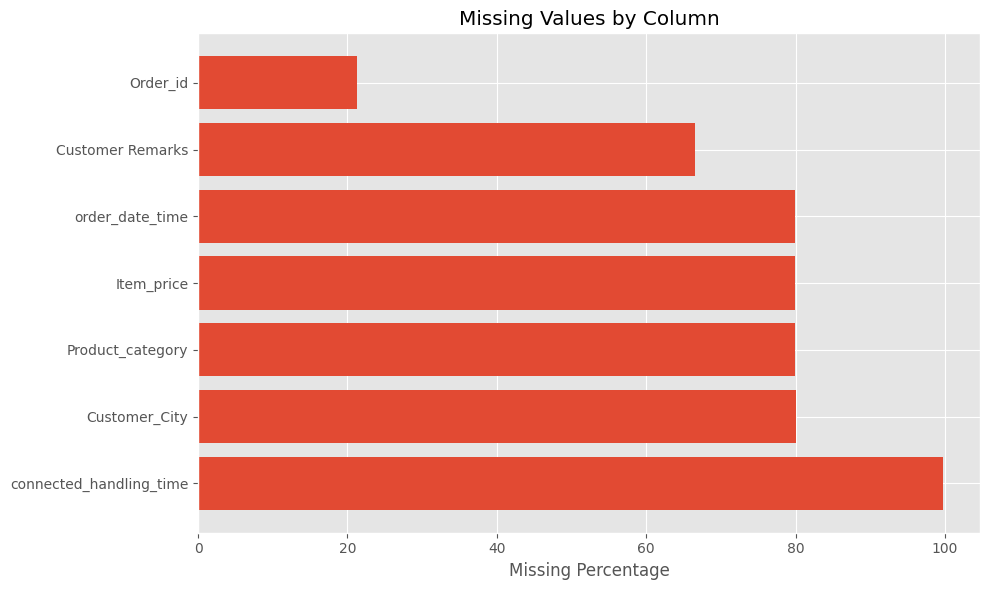

In [8]:
missing_plot = missing[missing["Missing %"] > 0]

plt.figure(figsize=(10,6))

plt.barh(
    missing_plot.index,
    missing_plot["Missing %"]
)

plt.xlabel("Missing Percentage")
plt.title("Missing Values by Column")

plt.tight_layout()
plt.show()

Several fields contain substantial missing values, particularly connected_handling_time, which is missing for the vast majority of records and will not be suitable for operational analysis. Customer remarks, product information, city, and order details also exhibit moderate missingness. In contrast, CSAT scores and most workflow-related fields are well populated, making them reliable inputs for customer satisfaction analysis and AI opportunity assessment.

In [9]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates:,}")

Duplicate rows: 0


In [10]:
df.dtypes

,0
Unique id,object
channel_name,object
category,object
Sub-category,object
Customer Remarks,object
Order_id,object
order_date_time,object
Issue_reported at,object
issue_responded,object
Survey_response_Date,object


# Initial Data Quality Summary

The dataset contains over 80,000 customer support interactions suitable for large-scale analytics.
Customer Satisfaction (CSAT) scores are nearly complete and will serve as the primary outcome variable.
Textual customer remarks are available for a meaningful subset of interactions, enabling natural language processing.
Several operational fields contain significant missing values and will either be excluded or handled appropriately during feature engineering.
Overall, the dataset provides sufficient information to support workflow analysis, customer intelligence, machine learning, and AI strategy development.

# **Feature Engineering**

# Business Objective

The raw dataset provides valuable operational information, but many of the most meaningful business insights cannot be obtained directly from the existing columns. This section engineers new features that capture customer behavior, complaint characteristics, and automation potential. These engineered variables will support subsequent workflow analysis, machine learning models, and AI investment recommendations.

In [11]:
# Create a working copy
df_fe = df.copy()

In [12]:
text_columns = [
    "Customer Remarks",
    "category",
    "Sub-category"
]

for col in text_columns:
    df_fe[col] = (
        df_fe[col]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.strip()
    )

In [13]:
df_fe["ticket_character_count"] = (
    df_fe["Customer Remarks"]
    .str.len()
)

df_fe["ticket_word_count"] = (
    df_fe["Customer Remarks"]
    .str.split()
    .str.len()
)

df_fe["ticket_sentence_count"] = (
    df_fe["Customer Remarks"]
    .str.count(r"[.!?]")
)

These features quantify the amount of information provided by the customer and may serve as indicators of complaint complexity.

In [14]:
df_fe["capital_letter_count"] = (
    df_fe["Customer Remarks"]
    .str.count(r"[A-Z]")
)

df_fe["capital_ratio"] = np.where(
    df_fe["ticket_character_count"] > 0,
    df_fe["capital_letter_count"] /
    df_fe["ticket_character_count"],
    0
)

In [15]:
# Standardize categorical text columns
categorical_text = [
    "category",
    "Sub-category"
]

for col in categorical_text:
    df_fe[col] = (
        df_fe[col]
        .fillna("")
        .astype(str)
        .str.lower()
        .str.strip()
    )

# Preserve original customer remarks while handling missing values
df_fe["Customer Remarks"] = (
    df_fe["Customer Remarks"]
    .fillna("")
    .astype(str)
)

# **Text Features**
# Generate Ticket Length Metrics

In [16]:
# ==========================================
# Generate Ticket Length Metrics
# ==========================================

# Total number of characters
df_fe["ticket_character_count"] = (
    df_fe["Customer Remarks"]
    .str.len()
)

# Total number of words
df_fe["ticket_word_count"] = (
    df_fe["Customer Remarks"]
    .str.split()
    .str.len()
)

# Number of sentences
df_fe["ticket_sentence_count"] = (
    df_fe["Customer Remarks"]
    .str.count(r"[.!?]")
)

# Average word length
df_fe["average_word_length"] = np.where(
    df_fe["ticket_word_count"] > 0,
    df_fe["ticket_character_count"] / df_fe["ticket_word_count"],
    0
)

In [17]:
# ==========================================
# Review Engineered Text Features
# ==========================================

df_fe[
    [
        "Customer Remarks",
        "ticket_character_count",
        "ticket_word_count",
        "ticket_sentence_count",
        "average_word_length"
    ]
].head(10)

,Customer Remarks,ticket_character_count,ticket_word_count,ticket_sentence_count,average_word_length
0,,0,0,0,0.000000
1,,0,0,0,0.000000
2,,0,0,0,0.000000
3,,0,0,0,0.000000
4,,0,0,0,0.000000
5,,0,0,0,0.000000
6,,0,0,0,0.000000
7,very good,9,2,0,4.500000
8,shopzilla app and it's all coustomer care services is very good service provided all time,89,15,0,5.933333
9,,0,0,0,0.000000


# **Text Features**
# **Measure Writing Style**

# Business Objective

Customers often communicate frustration through writing style rather than words alone. Excessive capitalization, repeated punctuation, and frequent question marks may indicate urgency or dissatisfaction. These features help quantify how customers express their complaints and may improve both customer satisfaction prediction and AI routing decisions.

In [18]:
# ==========================================
# Generate Writing Style Features
# ==========================================

# Count capital letters
df_fe["capital_letter_count"] = (
    df_fe["Customer Remarks"]
    .str.count(r"[A-Z]")
)

# Percentage of capital letters
df_fe["capital_ratio"] = np.where(
    df_fe["ticket_character_count"] > 0,
    df_fe["capital_letter_count"] /
    df_fe["ticket_character_count"],
    0
)

# Count question marks
df_fe["question_mark_count"] = (
    df_fe["Customer Remarks"]
    .str.count(r"\?")
)

# Count exclamation marks
df_fe["exclamation_mark_count"] = (
    df_fe["Customer Remarks"]
    .str.count(r"!")
)

In [19]:
# ==========================================
# Review Writing Style Features
# ==========================================

df_fe[
    [
        "Customer Remarks",
        "capital_letter_count",
        "capital_ratio",
        "question_mark_count",
        "exclamation_mark_count"
    ]
].head(10)

,Customer Remarks,capital_letter_count,capital_ratio,question_mark_count,exclamation_mark_count
0,,0,0.0,0,0
1,,0,0.0,0,0
2,,0,0.0,0,0
3,,0,0.0,0,0
4,,0,0.0,0,0
5,,0,0.0,0,0
6,,0,0.0,0,0
7,very good,0,0.0,0,0
8,shopzilla app and it's all coustomer care services is very good service provided all time,0,0.0,0,0
9,,0,0.0,0,0


These features quantify how customers communicate their concerns rather than what they are complaining about. Writing style indicators such as capitalization and punctuation may reflect urgency or emotional intensity and can provide additional signals for customer satisfaction prediction and AI-assisted ticket routing.

# **Complaint Features**
# **Detect Complaint Keywords**
# Business Objective

Certain complaint topics are more repetitive, operationally expensive, or unsuitable for automation than others. This section identifies the presence of key complaint themes within customer remarks by detecting business-relevant keywords. These features will later help evaluate workflow frequency, customer satisfaction, and AI automation potential.

In [20]:
# ==========================================
# Create Lowercase Text for Keyword Detection
# ==========================================

# Create a lowercase version of customer remarks for keyword searches
df_fe["remarks_lower"] = (
    df_fe["Customer Remarks"]
    .str.lower()
)

In [21]:
# ==========================================
# Detect Complaint Keywords
# ==========================================

# Dictionary of complaint keywords
complaint_keywords = {
    "refund": "refund",
    "delay": "delay|late|delivered late",
    "damaged": "damaged|broken|defective",
    "wrong_item": "wrong item|incorrect item|different item",
    "fraud": "fraud|fake|scam",
    "cancellation": "cancel|cancellation",
    "payment": "payment|paid|charged",
    "replacement": "replace|replacement",
    "missing_item": "missing|not received"
}

# Create binary indicator columns
for feature, pattern in complaint_keywords.items():
    df_fe[f"{feature}_mention"] = (
        df_fe["remarks_lower"]
        .str.contains(pattern, regex=True, na=False)
        .astype(int)
    )

In [22]:
# ==========================================
# Review Complaint Features
# ==========================================

keyword_columns = [
    "Customer Remarks",
    "refund_mention",
    "delay_mention",
    "damaged_mention",
    "wrong_item_mention",
    "fraud_mention",
    "cancellation_mention",
    "payment_mention",
    "replacement_mention",
    "missing_item_mention"
]

df_fe[keyword_columns].sample(10, random_state=42)

,Customer Remarks,refund_mention,delay_mention,damaged_mention,wrong_item_mention,fraud_mention,cancellation_mention,payment_mention,replacement_mention,missing_item_mention
67871,,0,0,0,0,0,0,0,0,0
40187,retain employees like this guy. short and simple conversation.,0,0,0,0,0,0,0,0,0
60075,,0,0,0,0,0,0,0,0,0
69560,trusted 100/,0,0,0,0,0,0,0,0,0
2605,,0,0,0,0,0,0,0,0,0
73327,,0,0,0,0,0,0,0,0,0
4382,,0,0,0,0,0,0,0,0,0
10405,thank you shopzilla,0,0,0,0,0,0,0,0,0
24494,,0,0,0,0,0,0,0,0,0
5473,,0,0,0,0,0,0,0,0,0


# **Complaint Features**
# **Identify Customer Support Workflows**
# Business Objective
Rather than analyzing isolated keywords, this section groups related customer complaints into common business workflows. These engineered features represent the types of support requests handled by customer service teams and provide a more meaningful foundation for workflow analysis, automation readiness, and AI investment decisions.

In [23]:
# ==========================================
# Define Customer Support Workflows
# ==========================================

workflow_keywords = {

    "refund_workflow":
        r"refund|reimbursement|money back|return my money",

    "delivery_workflow":
        r"delay|late|shipping|delivery|courier|dispatch|not delivered",

    "product_quality_workflow":
        r"damaged|broken|defective|faulty|poor quality",

    "order_issue_workflow":
        r"wrong item|incorrect item|missing item|different item|incomplete order",

    "payment_workflow":
        r"payment|charged|debit|credit card|upi|transaction|billing",

    "account_workflow":
        r"login|password|account|otp|verification",

    "cancellation_workflow":
        r"cancel|cancellation",

    "replacement_workflow":
        r"replace|replacement|exchange",

    "fraud_workflow":
        r"fraud|fake|scam|counterfeit"

}

In [24]:
# ==========================================
# Generate Workflow Features
# ==========================================

for workflow, pattern in workflow_keywords.items():
    df_fe[workflow] = (
        df_fe["remarks_lower"]
            .str.contains(pattern, regex=True, na=False)
            .astype(int)
    )

In [25]:
# ==========================================
# Review Workflow Features
# ==========================================

workflow_columns = [
    "Customer Remarks",
    "refund_workflow",
    "delivery_workflow",
    "product_quality_workflow",
    "order_issue_workflow",
    "payment_workflow",
    "account_workflow",
    "cancellation_workflow",
    "replacement_workflow",
    "fraud_workflow"
]

df_fe[workflow_columns].sample(10, random_state=42)

,Customer Remarks,refund_workflow,delivery_workflow,product_quality_workflow,order_issue_workflow,payment_workflow,account_workflow,cancellation_workflow,replacement_workflow,fraud_workflow
67871,,0,0,0,0,0,0,0,0,0
40187,retain employees like this guy. short and simple conversation.,0,0,0,0,0,0,0,0,0
60075,,0,0,0,0,0,0,0,0,0
69560,trusted 100/,0,0,0,0,0,0,0,0,0
2605,,0,0,0,0,0,0,0,0,0
73327,,0,0,0,0,0,0,0,0,0
4382,,0,0,0,0,0,0,0,0,0
10405,thank you shopzilla,0,0,0,0,0,0,0,0,0
24494,,0,0,0,0,0,0,0,0,0
5473,,0,0,0,0,0,0,0,0,0


Instead of treating every complaint independently, the engineered workflow features classify tickets into broader operational processes such as refunds, deliveries, payments, and product quality issues. This approach better reflects how customer support organizations allocate resources and provides a stronger foundation for identifying workflows that are suitable for AI-assisted automation.

# **Complaint Features**
# **Explore Existing Workflow Labels**
# Business Objective
Before engineering custom workflow features, examine the existing support categories to understand how customer issues are currently classified. This helps determine whether the predefined taxonomy is sufficient or whether additional business logic is required.

In [26]:
# ==========================================
# Review Existing Support Categories
# ==========================================

print("Category Values:\n")
print(df_fe["category"].value_counts(dropna=False))

print("\n" + "="*60 + "\n")

print("Sub-category Values:\n")
print(df_fe["Sub-category"].value_counts(dropna=False))

Category Values:

category
returns               44097
order related         23215
refund related         4550
product queries        3692
shopzilla related      2792
payments related       2327
feedback               2294
cancellation           2212
offers & cashback       480
others                   99
app/website              84
onboarding related       65
Name: count, dtype: int64


Sub-category Values:

Sub-category
reverse pickup enquiry              22389
return request                       8523
delayed                              7388
order status enquiry                 6922
installation/demo                    4116
fraudulent user                      4108
product specific information         3589
refund enquiry                       2665
wrong                                2597
missing                              2556
unprofessional behaviour             2294
general enquiry                      1945
not needed                           1920
service centres related     

# **Complaint Features**
# **Explore Existing Workflow Labels**
# Business Objective
Before creating custom workflow classifications, it is important to understand how Flipkart currently categorizes customer support requests. Examining the existing taxonomy helps identify whether current classifications are sufficient or whether additional feature engineering is required to better support AI investment decisions.

In [27]:
# ==========================================
# Review Existing Support Categories
# ==========================================

print("=" * 60)
print("CATEGORY")
print("=" * 60)

display(
    df_fe["category"]
    .value_counts(dropna=False)
    .to_frame("Ticket Count")
)

print("\n")

print("=" * 60)
print("SUB-CATEGORY")
print("=" * 60)

display(
    df_fe["Sub-category"]
    .value_counts(dropna=False)
    .to_frame("Ticket Count")
)

CATEGORY


,Ticket Count
category,
returns,44097
order related,23215
refund related,4550
product queries,3692
shopzilla related,2792
payments related,2327
feedback,2294
cancellation,2212
offers & cashback,480




SUB-CATEGORY


,Ticket Count
Sub-category,
reverse pickup enquiry,22389
return request,8523
delayed,7388
order status enquiry,6922
installation/demo,4116
fraudulent user,4108
product specific information,3589
refund enquiry,2665
wrong,2597


In [28]:
# ==========================================
# Review Category & Sub-category Relationships
# ==========================================

category_mapping = (
    df_fe
    .groupby(["category", "Sub-category"])
    .size()
    .reset_index(name="Ticket Count")
    .sort_values("Ticket Count", ascending=False)
)

category_mapping.head(30)

,category,Sub-category,Ticket Count
46,returns,reverse pickup enquiry,22389
45,returns,return request,8523
11,order related,delayed,7388
15,order related,order status enquiry,6922
13,order related,installation/demo,4116
41,returns,fraudulent user,4108
34,product queries,product specific information,3589
37,refund related,refund enquiry,2665
51,returns,wrong,2597
43,returns,missing,2556


# **Analyze Ticket Distribution by Category**
# **Business Objective**
Determine which customer support categories generate the highest ticket volumes. High-volume workflows represent the greatest opportunity for AI-assisted automation because even small efficiency improvements can produce significant operational savings.

In [29]:
# ==========================================
# Analyze Ticket Distribution by Category
# ==========================================

category_summary = (
    df_fe["category"]
    .value_counts()
    .reset_index()
)

category_summary.columns = ["Category", "Ticket Count"]

category_summary["Percentage"] = (
    category_summary["Ticket Count"] /
    category_summary["Ticket Count"].sum() * 100
).round(2)

category_summary

,Category,Ticket Count,Percentage
0,returns,44097,51.33
1,order related,23215,27.02
2,refund related,4550,5.30
3,product queries,3692,4.30
4,shopzilla related,2792,3.25
5,payments related,2327,2.71
6,feedback,2294,2.67
7,cancellation,2212,2.57
8,offers & cashback,480,0.56
9,others,99,0.12


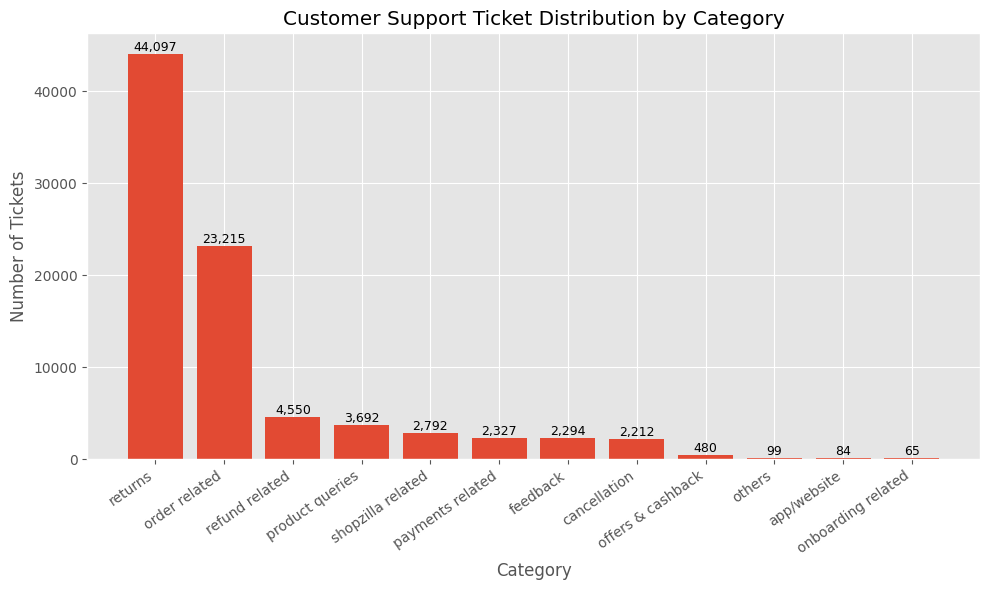

In [30]:
# ==========================================
# Visualize Ticket Distribution
# ==========================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    category_summary["Category"],
    category_summary["Ticket Count"]
)

plt.title("Customer Support Ticket Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=35, ha="right")

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

Customer support demand is highly concentrated within a small number of operational workflows. Returns and Order Related account for the majority of all customer interactions, while the remaining categories individually contribute relatively small volumes. This concentration suggests that AI investments targeting these high-volume workflows have the greatest potential to reduce operational workload and improve overall efficiency.

# **Which Workflows Create the Greatest Customer Pain?**
# Business Objective
While ticket volume indicates where support teams spend the most effort, it does not necessarily reflect where customers experience the greatest frustration. This section evaluates customer satisfaction across different support workflows to identify areas where AI-assisted improvements could have the greatest impact on customer experience.

In [31]:
# ==========================================
# Analyze Average CSAT by Category
# ==========================================

csat_by_category = (
    df_fe
    .groupby("category")
    .agg(
        Average_CSAT=("CSAT Score", "mean"),
        Ticket_Count=("CSAT Score", "count")
    )
    .round(2)
    .sort_values("Average_CSAT")
    .reset_index()
)

csat_by_category

,category,Average_CSAT,Ticket_Count
0,others,3.43,99
1,cancellation,3.99,2212
2,product queries,4.04,3692
3,order related,4.10,23215
4,feedback,4.16,2294
5,offers & cashback,4.21,480
6,refund related,4.23,4550
7,onboarding related,4.26,65
8,shopzilla related,4.31,2792
9,payments related,4.35,2327


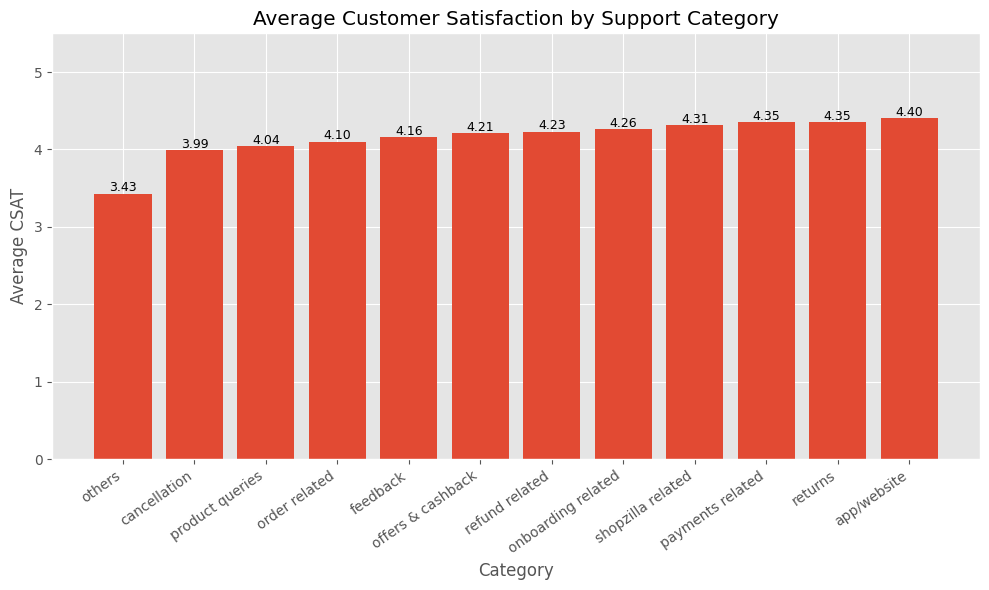

In [32]:
# ==========================================
# Visualize Average CSAT by Category
# ==========================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    csat_by_category["category"],
    csat_by_category["Average_CSAT"]
)

plt.title("Average Customer Satisfaction by Support Category")
plt.xlabel("Category")
plt.ylabel("Average CSAT")
plt.xticks(rotation=35, ha="right")

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.03,
        f"{height:.2f}",
        ha="center",
        fontsize=9
    )

plt.ylim(0,5.5)

plt.tight_layout()
plt.show()

In [33]:
# ==========================================
# Combine Ticket Volume and Average CSAT
# ==========================================

category_performance = (
    category_summary
    .merge(
        csat_by_category,
        left_on="Category",
        right_on="category"
    )
    .drop(columns="category")
)

category_performance

,Category,Ticket Count,Percentage,Average_CSAT,Ticket_Count
0,returns,44097,51.33,4.35,44097
1,order related,23215,27.02,4.10,23215
2,refund related,4550,5.30,4.23,4550
3,product queries,3692,4.30,4.04,3692
4,shopzilla related,2792,3.25,4.31,2792
5,payments related,2327,2.71,4.35,2327
6,feedback,2294,2.67,4.16,2294
7,cancellation,2212,2.57,3.99,2212
8,offers & cashback,480,0.56,4.21,480
9,others,99,0.12,3.43,99


# **Workflow Intelligence**
# **Executive Question 3: Which Specific Workflows Should Flipkart Prioritize for AI?**
# Business Objective
While category-level analysis provides a high-level view of customer support operations, AI investments are implemented at the workflow level. This section identifies the specific support workflows that generate the highest ticket volumes and the lowest customer satisfaction, enabling more targeted recommendations for AI-assisted automation.

# Analyze Workflow Performance
# Business Objective
Evaluate customer satisfaction and ticket volume at the sub-category level to identify operational workflows that contribute most to customer dissatisfaction.

In [34]:
# ==========================================
# Analyze Workflow Performance
# ==========================================

workflow_performance = (
    df_fe
    .groupby("Sub-category")
    .agg(
        Ticket_Count=("CSAT Score", "count"),
        Average_CSAT=("CSAT Score", "mean")
    )
    .round(2)
    .sort_values("Ticket_Count", ascending=False)
    .reset_index()
)

workflow_performance.head(20)

,Sub-category,Ticket_Count,Average_CSAT
0,reverse pickup enquiry,22389,4.19
1,return request,8523,4.61
2,delayed,7388,4.01
3,order status enquiry,6922,4.21
4,installation/demo,4116,3.88
5,fraudulent user,4108,4.59
6,product specific information,3589,4.04
7,refund enquiry,2665,4.30
8,wrong,2597,4.53
9,missing,2556,4.61


In [35]:
# ==========================================
# Filter High-Volume Workflows
# ==========================================

high_volume_workflows = (
    workflow_performance[
        workflow_performance["Ticket_Count"] >= 500
    ]
    .sort_values("Ticket_Count", ascending=False)
)

high_volume_workflows

,Sub-category,Ticket_Count,Average_CSAT
0,reverse pickup enquiry,22389,4.19
1,return request,8523,4.61
2,delayed,7388,4.01
3,order status enquiry,6922,4.21
4,installation/demo,4116,3.88
5,fraudulent user,4108,4.59
6,product specific information,3589,4.04
7,refund enquiry,2665,4.30
8,wrong,2597,4.53
9,missing,2556,4.61


In [36]:
# ==========================================
# Rank High-Volume Workflows by CSAT
# ==========================================

high_volume_workflows.sort_values(
    "Average_CSAT"
)

,Sub-category,Ticket_Count,Average_CSAT
17,seller cancelled order,1059,3.58
4,installation/demo,4116,3.88
12,not needed,1920,3.92
2,delayed,7388,4.01
6,product specific information,3589,4.04
19,exchange / replacement,896,4.07
13,service centres related,1875,4.12
14,refund related issues,1800,4.14
10,unprofessional behaviour,2294,4.16
0,reverse pickup enquiry,22389,4.19


# **Workflow Intelligence**
# **Executive Question 4: Which Specific Workflows Should Flipkart Improve First?**
# Business Objective
High-level categories such as Returns and Order Related provide useful context, but AI investments are implemented at the workflow level. This section drills down into individual support workflows to identify those with the greatest operational burden and the poorest customer experience.

In [37]:
# ==========================================
# Summarize Performance by Workflow
# ==========================================

workflow_summary = (
    df_fe
    .groupby("Sub-category")
    .agg(
        Ticket_Count=("CSAT Score", "count"),
        Average_CSAT=("CSAT Score", "mean")
    )
    .round(2)
    .sort_values("Ticket_Count", ascending=False)
    .reset_index()
)

workflow_summary

,Sub-category,Ticket_Count,Average_CSAT
0,reverse pickup enquiry,22389,4.19
1,return request,8523,4.61
2,delayed,7388,4.01
3,order status enquiry,6922,4.21
4,installation/demo,4116,3.88
5,fraudulent user,4108,4.59
6,product specific information,3589,4.04
7,refund enquiry,2665,4.30
8,wrong,2597,4.53
9,missing,2556,4.61


In [38]:
# ==========================================
# Filter High-Volume Workflows
# ==========================================

high_volume_workflows = (
    workflow_summary
    .query("Ticket_Count >= 500")
    .sort_values("Ticket_Count", ascending=False)
)

high_volume_workflows

,Sub-category,Ticket_Count,Average_CSAT
0,reverse pickup enquiry,22389,4.19
1,return request,8523,4.61
2,delayed,7388,4.01
3,order status enquiry,6922,4.21
4,installation/demo,4116,3.88
5,fraudulent user,4108,4.59
6,product specific information,3589,4.04
7,refund enquiry,2665,4.30
8,wrong,2597,4.53
9,missing,2556,4.61


In [39]:
# ==========================================
# Rank Workflows by Average CSAT
# ==========================================

high_volume_workflows.sort_values(
    by="Average_CSAT"
)

,Sub-category,Ticket_Count,Average_CSAT
17,seller cancelled order,1059,3.58
4,installation/demo,4116,3.88
12,not needed,1920,3.92
2,delayed,7388,4.01
6,product specific information,3589,4.04
19,exchange / replacement,896,4.07
13,service centres related,1875,4.12
14,refund related issues,1800,4.14
10,unprofessional behaviour,2294,4.16
0,reverse pickup enquiry,22389,4.19


# **Workflow Opportunity Matrix**
# **Which Workflows Should Flipkart Prioritize for AI Investment?**
# **Business Objective**
Not all customer support workflows deserve equal investment. This visualization compares operational demand with customer satisfaction to identify workflows that have the greatest potential for improvement. High-volume workflows with relatively lower customer satisfaction represent the strongest candidates for AI-assisted optimization.

In [40]:
# ==========================================
# Prepare Data for Opportunity Matrix
# ==========================================

opportunity_df = high_volume_workflows.copy()

# Calculate each workflow's share of total tickets
opportunity_df["Ticket Share (%)"] = (
    opportunity_df["Ticket_Count"] /
    opportunity_df["Ticket_Count"].sum() * 100
).round(2)

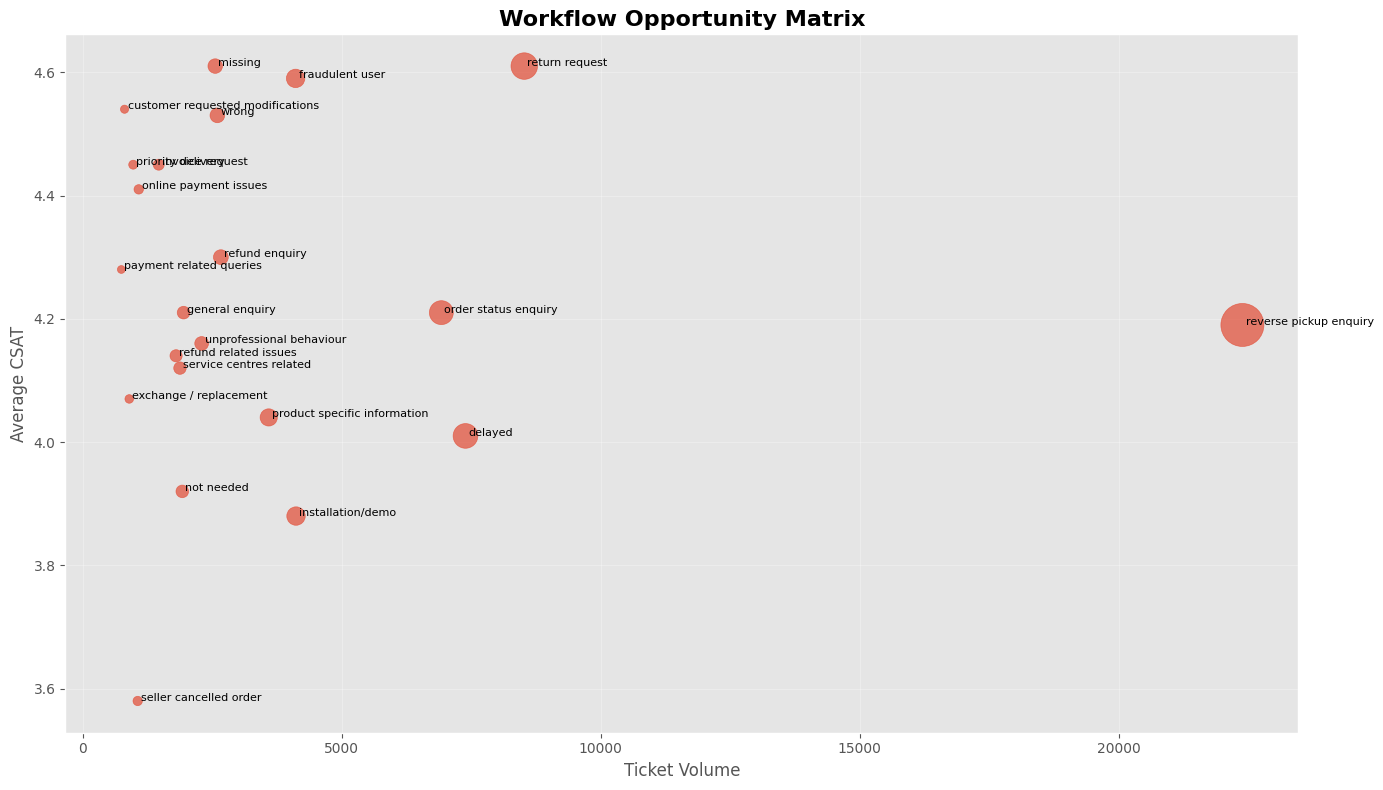

In [41]:
# ==========================================
# Create Workflow Opportunity Matrix
# ==========================================

plt.figure(figsize=(14,8))

scatter = plt.scatter(
    opportunity_df["Ticket_Count"],
    opportunity_df["Average_CSAT"],
    s=opportunity_df["Ticket Share (%)"] * 35,
    alpha=0.7
)

# Add workflow labels
for _, row in opportunity_df.iterrows():
    plt.text(
        row["Ticket_Count"] + 60,
        row["Average_CSAT"],
        row["Sub-category"],
        fontsize=8
    )

plt.title(
    "Workflow Opportunity Matrix",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Ticket Volume")
plt.ylabel("Average CSAT")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

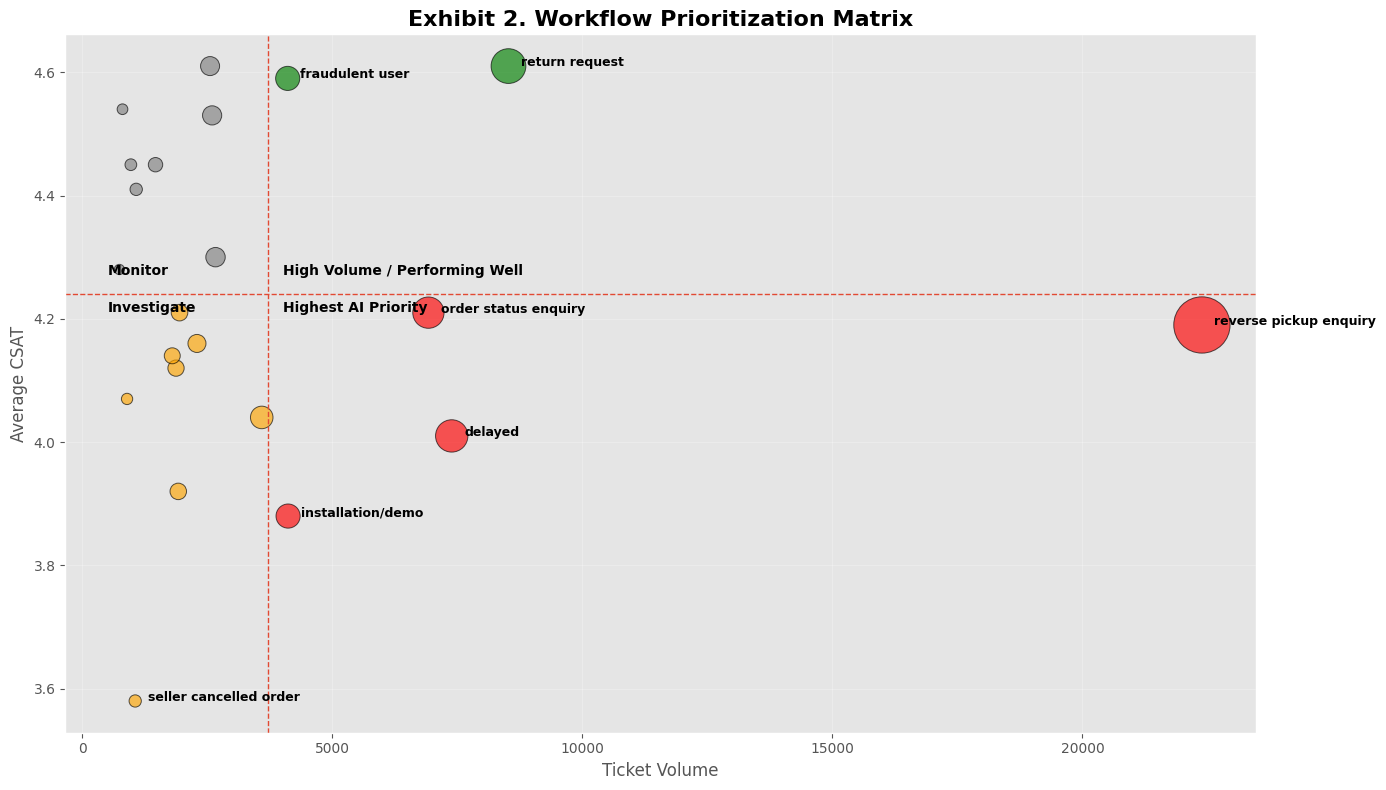

In [42]:
# ==========================================
# Create Executive Workflow Opportunity Matrix
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

plot_df = opportunity_df.copy()

# Define reference lines
avg_ticket_volume = plot_df["Ticket_Count"].mean()
avg_csat = plot_df["Average_CSAT"].mean()

# Assign priority zones
def assign_priority(row):
    if row["Ticket_Count"] >= avg_ticket_volume and row["Average_CSAT"] < avg_csat:
        return "Highest AI Priority"
    elif row["Ticket_Count"] >= avg_ticket_volume and row["Average_CSAT"] >= avg_csat:
        return "High Volume / Performing Well"
    elif row["Ticket_Count"] < avg_ticket_volume and row["Average_CSAT"] < avg_csat:
        return "Investigate"
    else:
        return "Monitor"

plot_df["Priority Zone"] = plot_df.apply(assign_priority, axis=1)

# Color mapping
color_map = {
    "Highest AI Priority": "red",
    "High Volume / Performing Well": "green",
    "Investigate": "orange",
    "Monitor": "gray"
}

plot_df["Color"] = plot_df["Priority Zone"].map(color_map)

plt.figure(figsize=(14, 8))

plt.scatter(
    plot_df["Ticket_Count"],
    plot_df["Average_CSAT"],
    s=plot_df["Ticket Share (%)"] * 60,
    c=plot_df["Color"],
    alpha=0.65,
    edgecolors="black",
    linewidth=0.7
)

# Quadrant reference lines
plt.axvline(
    avg_ticket_volume,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    avg_csat,
    linestyle="--",
    linewidth=1
)

# Label only the most important workflows
label_workflows = [
    "reverse pickup enquiry",
    "return request",
    "delayed",
    "order status enquiry",
    "installation/demo",
    "seller cancelled order",
    "fraudulent user"
]

for _, row in plot_df.iterrows():
    if row["Sub-category"] in label_workflows:
        plt.text(
            row["Ticket_Count"] + 250,
            row["Average_CSAT"],
            row["Sub-category"],
            fontsize=9,
            weight="bold"
        )

plt.title(
    "Exhibit 2. Workflow Prioritization Matrix",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Ticket Volume")
plt.ylabel("Average CSAT")

plt.text(
    avg_ticket_volume + 300,
    avg_csat - 0.03,
    "Highest AI Priority",
    fontsize=10,
    weight="bold"
)

plt.text(
    avg_ticket_volume + 300,
    avg_csat + 0.03,
    "High Volume / Performing Well",
    fontsize=10,
    weight="bold"
)

plt.text(
    500,
    avg_csat - 0.03,
    "Investigate",
    fontsize=10,
    weight="bold"
)

plt.text(
    500,
    avg_csat + 0.03,
    "Monitor",
    fontsize=10,
    weight="bold"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

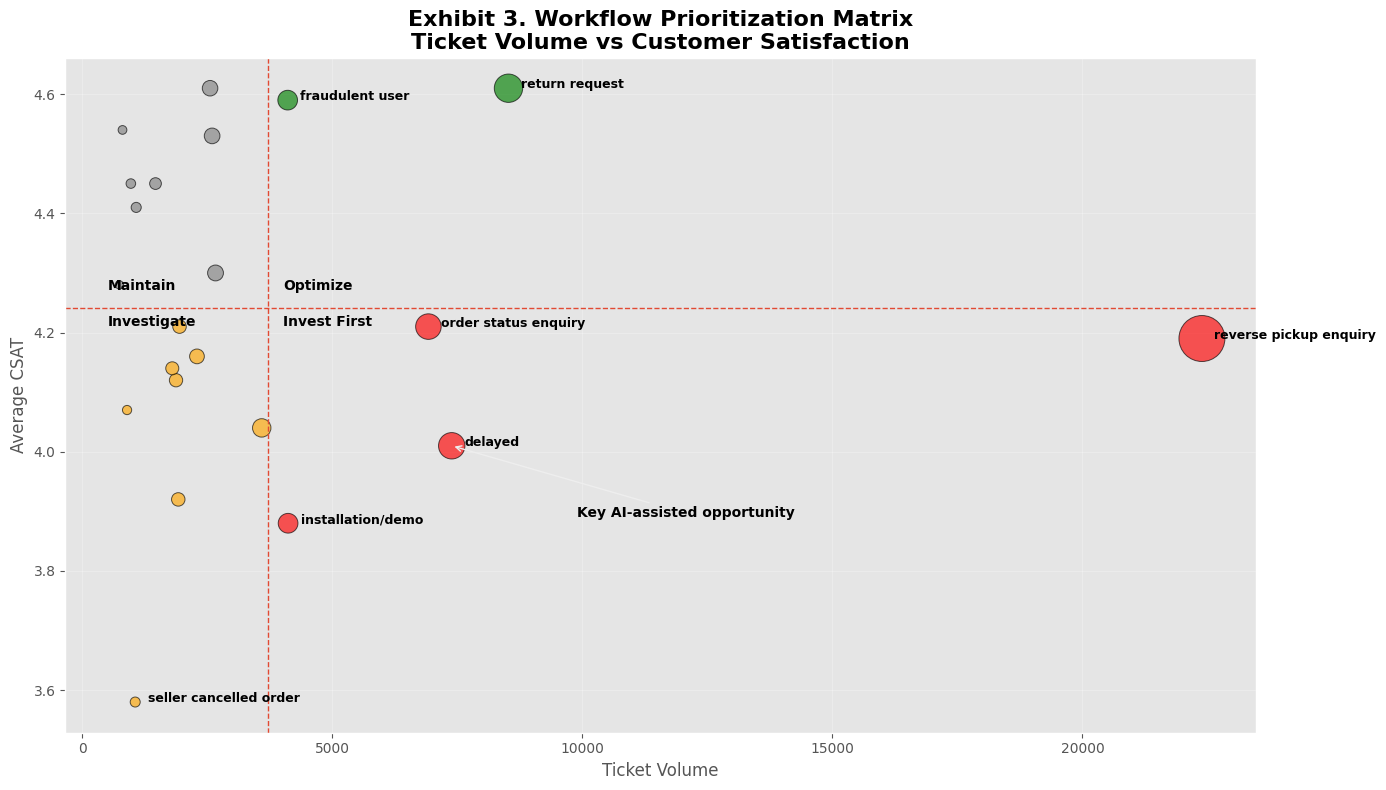

In [43]:
# ==========================================
# Create Final Executive Workflow Prioritization Matrix
# ==========================================

plot_df = opportunity_df.copy()

# Define reference lines
avg_ticket_volume = plot_df["Ticket_Count"].mean()
avg_csat = plot_df["Average_CSAT"].mean()

# Assign executive priority zones
def assign_priority(row):
    if row["Ticket_Count"] >= avg_ticket_volume and row["Average_CSAT"] < avg_csat:
        return "Invest First"
    elif row["Ticket_Count"] >= avg_ticket_volume and row["Average_CSAT"] >= avg_csat:
        return "Optimize"
    elif row["Ticket_Count"] < avg_ticket_volume and row["Average_CSAT"] < avg_csat:
        return "Investigate"
    else:
        return "Maintain"

plot_df["Priority Zone"] = plot_df.apply(assign_priority, axis=1)

# Color mapping
color_map = {
    "Invest First": "red",
    "Optimize": "green",
    "Investigate": "orange",
    "Maintain": "gray"
}

plot_df["Color"] = plot_df["Priority Zone"].map(color_map)

plt.figure(figsize=(14, 8))

plt.scatter(
    plot_df["Ticket_Count"],
    plot_df["Average_CSAT"],
    s=plot_df["Ticket Share (%)"] * 40,
    c=plot_df["Color"],
    alpha=0.65,
    edgecolors="black",
    linewidth=0.7
)

# Add quadrant lines
plt.axvline(
    avg_ticket_volume,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    avg_csat,
    linestyle="--",
    linewidth=1
)

# Label only the important workflows
label_workflows = [
    "reverse pickup enquiry",
    "return request",
    "delayed",
    "order status enquiry",
    "installation/demo",
    "seller cancelled order",
    "fraudulent user"
]

for _, row in plot_df.iterrows():
    if row["Sub-category"] in label_workflows:
        plt.text(
            row["Ticket_Count"] + 250,
            row["Average_CSAT"],
            row["Sub-category"],
            fontsize=9,
            weight="bold"
        )

# Highlight one key opportunity
delayed_row = plot_df[plot_df["Sub-category"] == "delayed"]

if not delayed_row.empty:
    x = delayed_row["Ticket_Count"].values[0]
    y = delayed_row["Average_CSAT"].values[0]

    plt.annotate(
        "Key AI-assisted opportunity",
        xy=(x, y),
        xytext=(x + 2500, y - 0.12),
        arrowprops=dict(arrowstyle="->", linewidth=1),
        fontsize=10,
        weight="bold"
    )

# Add quadrant labels
plt.text(
    avg_ticket_volume + 300,
    avg_csat - 0.03,
    "Invest First",
    fontsize=10,
    weight="bold"
)

plt.text(
    avg_ticket_volume + 300,
    avg_csat + 0.03,
    "Optimize",
    fontsize=10,
    weight="bold"
)

plt.text(
    500,
    avg_csat - 0.03,
    "Investigate",
    fontsize=10,
    weight="bold"
)

plt.text(
    500,
    avg_csat + 0.03,
    "Maintain",
    fontsize=10,
    weight="bold"
)

plt.title(
    "Exhibit 3. Workflow Prioritization Matrix\nTicket Volume vs Customer Satisfaction",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Ticket Volume")
plt.ylabel("Average CSAT")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# **Interpretation**
Customer support demand is concentrated within a small number of operational workflows; however, high ticket volume does not necessarily mean poor customer experience. Return-related workflows generate the largest share of support interactions, but most maintain strong CSAT. In contrast, order fulfillment workflows such as Delayed, Installation/Demo, and Seller Cancelled Order show weaker satisfaction despite meaningful ticket volume.
## **Business Impact**
This suggests that customer dissatisfaction is driven more by fulfillment and operational execution than by the support process itself. AI should therefore be used not just to answer tickets faster, but to reduce avoidable contacts through proactive delivery updates, installation scheduling support, seller monitoring, and clearer order communication.
# **Executive Takeaway**
Flipkart should prioritize AI investment in order fulfillment workflows before expanding automation across returns. Returns create the most volume, but order-related issues create the clearer customer experience opportunity.

# **AI Opportunity Assessment**
# Where Should AI Be Applied Across Customer Support Workflows?
# Business Objective
Not every customer support workflow should be fully automated. Some interactions involve repetitive information retrieval, while others require operational coordination or human judgment. This section introduces a structured decision framework to determine the most appropriate role for AI within each support workflow.

In [44]:
# ==========================================
# Create AI Decision Framework
# ==========================================

ai_framework = {
    "reverse pickup enquiry": {
        "Repetitiveness": "High",
        "Human_Judgment": "Medium",
        "Operational_Dependency": "High"
    },
    "return request": {
        "Repetitiveness": "High",
        "Human_Judgment": "Medium",
        "Operational_Dependency": "Medium"
    },
    "delayed": {
        "Repetitiveness": "High",
        "Human_Judgment": "Low",
        "Operational_Dependency": "High"
    },
    "order status enquiry": {
        "Repetitiveness": "Very High",
        "Human_Judgment": "Low",
        "Operational_Dependency": "Low"
    },
    "installation/demo": {
        "Repetitiveness": "Medium",
        "Human_Judgment": "Medium",
        "Operational_Dependency": "High"
    },
    "fraudulent user": {
        "Repetitiveness": "Low",
        "Human_Judgment": "Very High",
        "Operational_Dependency": "Medium"
    },
    "refund enquiry": {
        "Repetitiveness": "High",
        "Human_Judgment": "Medium",
        "Operational_Dependency": "Medium"
    },
    "seller cancelled order": {
        "Repetitiveness": "Low",
        "Human_Judgment": "Very High",
        "Operational_Dependency": "Very High"
    },
    "invoice request": {
        "Repetitiveness": "Very High",
        "Human_Judgment": "Low",
        "Operational_Dependency": "Low"
    },
    "online payment issues": {
        "Repetitiveness": "High",
        "Human_Judgment": "Medium",
        "Operational_Dependency": "Low"
    }
}

# **Create AI Decision Matrix**

In [45]:
# ==========================================
# Create AI Decision Matrix
# ==========================================

import pandas as pd

ai_decision_matrix = pd.DataFrame({

    "Workflow":[
        "order status enquiry",
        "invoice request",
        "online payment issues",
        "payment related queries",
        "delayed",
        "reverse pickup enquiry",
        "return request",
        "refund enquiry",
        "installation/demo",
        "exchange / replacement",
        "fraudulent user",
        "seller cancelled order"
    ],

    "Repetitiveness":[
        5,5,5,5,
        5,4,4,4,
        3,3,
        1,2
    ],

    "Human_Judgment":[
        1,1,2,2,
        2,2,2,3,
        3,3,
        5,5
    ],

    "Operational_Dependency":[
        1,1,2,2,
        5,4,3,3,
        5,4,
        3,5
    ]

})

ai_decision_matrix

,Workflow,Repetitiveness,Human_Judgment,Operational_Dependency
0,order status enquiry,5,1,1
1,invoice request,5,1,1
2,online payment issues,5,2,2
3,payment related queries,5,2,2
4,delayed,5,2,5
5,reverse pickup enquiry,4,2,4
6,return request,4,2,3
7,refund enquiry,4,3,3
8,installation/demo,3,3,5
9,exchange / replacement,3,3,4


In [46]:
# ==========================================
# Assign AI Recommendation
# ==========================================

def recommend_ai(row):

    if (
        row["Repetitiveness"] >= 4
        and row["Human_Judgment"] <= 2
        and row["Operational_Dependency"] <= 2
    ):
        return "Fully Automate"

    elif row["Human_Judgment"] >= 4:
        return "Human-Led"

    else:
        return "AI-Assisted"

ai_decision_matrix["AI_Recommendation"] = (
    ai_decision_matrix.apply(recommend_ai, axis=1)
)

ai_decision_matrix

,Workflow,Repetitiveness,Human_Judgment,Operational_Dependency,AI_Recommendation
0,order status enquiry,5,1,1,Fully Automate
1,invoice request,5,1,1,Fully Automate
2,online payment issues,5,2,2,Fully Automate
3,payment related queries,5,2,2,Fully Automate
4,delayed,5,2,5,AI-Assisted
5,reverse pickup enquiry,4,2,4,AI-Assisted
6,return request,4,2,3,AI-Assisted
7,refund enquiry,4,3,3,AI-Assisted
8,installation/demo,3,3,5,AI-Assisted
9,exchange / replacement,3,3,4,AI-Assisted


| Score | Repetitiveness                          | Human Judgment                                 | Operational Dependency                                          |
| ----: | --------------------------------------- | ---------------------------------------------- | --------------------------------------------------------------- |
| **1** | Rare, highly variable interactions      | Extensive investigation or discretion required | Resolution entirely within customer support                     |
| **2** | Mostly unique interactions              | Moderate interpretation required               | Limited coordination with other teams                           |
| **3** | Mix of repetitive and unique tasks      | Moderate business judgment                     | Shared responsibility across teams                              |
| **4** | Frequently repeated interactions        | Minimal judgment required                      | Significant coordination with logistics, sellers, or operations |
| **5** | Highly standardized, repetitive process | Little or no judgment required                 | Resolution depends heavily on external operational processes    |


# **AI Workflow Prioritization Framework**
# **Which Workflows Should Flipkart Prioritize for AI Investment?**
# Business Objective
AI should not be deployed uniformly across customer support operations. Instead, investments should focus on workflows where automation can improve efficiency while maintaining customer experience and minimizing business risk. This framework evaluates each major workflow using standardized business criteria to determine the most appropriate role for AI.

| Evaluation Dimension       | Business Question                                                                     | High Score Indicates                        |
| -------------------------- | ------------------------------------------------------------------------------------- | ------------------------------------------- |
| **Repetitiveness**         | Does the workflow involve answering similar customer requests repeatedly?             | Strong automation candidate                 |
| **Human Judgment**         | Does resolving the issue require investigation, discretion, or policy interpretation? | Greater need for human involvement          |
| **Operational Dependency** | Does successful resolution depend on logistics, sellers, or other business functions? | AI should assist rather than fully automate |


In [47]:
# ==========================================
# Create AI Workflow Prioritization Matrix
# ==========================================

ai_matrix = pd.DataFrame({

    "Workflow":[
        "reverse pickup enquiry",
        "return request",
        "delayed",
        "order status enquiry",
        "installation/demo",
        "fraudulent user",
        "product specific information",
        "refund enquiry",
        "wrong",
        "missing",
        "invoice request",
        "online payment issues",
        "seller cancelled order",
        "exchange / replacement"
    ],

    "Repetitiveness":[
        4,
        5,
        5,
        5,
        3,
        1,
        5,
        4,
        3,
        3,
        5,
        5,
        2,
        3
    ],

    "Human_Judgment":[
        2,
        2,
        2,
        1,
        3,
        5,
        1,
        3,
        3,
        3,
        1,
        2,
        5,
        3
    ],

    "Operational_Dependency":[
        4,
        3,
        5,
        1,
        5,
        3,
        1,
        3,
        4,
        4,
        1,
        2,
        5,
        4
    ]

})

ai_matrix

,Workflow,Repetitiveness,Human_Judgment,Operational_Dependency
0,reverse pickup enquiry,4,2,4
1,return request,5,2,3
2,delayed,5,2,5
3,order status enquiry,5,1,1
4,installation/demo,3,3,5
5,fraudulent user,1,5,3
6,product specific information,5,1,1
7,refund enquiry,4,3,3
8,wrong,3,3,4
9,missing,3,3,4


In [48]:
# ==========================================
# Generate AI Recommendations
# ==========================================

def classify_ai(row):

    if (
        row["Repetitiveness"] >= 4
        and row["Human_Judgment"] <= 2
        and row["Operational_Dependency"] <= 2
    ):
        return "Fully Automate"

    elif (
        row["Human_Judgment"] >= 4
        or row["Operational_Dependency"] >= 5
    ):
        return "Human-Led"

    else:
        return "AI-Assisted"

ai_matrix["AI_Recommendation"] = (
    ai_matrix.apply(classify_ai, axis=1)
)

ai_matrix

,Workflow,Repetitiveness,Human_Judgment,Operational_Dependency,AI_Recommendation
0,reverse pickup enquiry,4,2,4,AI-Assisted
1,return request,5,2,3,AI-Assisted
2,delayed,5,2,5,Human-Led
3,order status enquiry,5,1,1,Fully Automate
4,installation/demo,3,3,5,Human-Led
5,fraudulent user,1,5,3,Human-Led
6,product specific information,5,1,1,Fully Automate
7,refund enquiry,4,3,3,AI-Assisted
8,wrong,3,3,4,AI-Assisted
9,missing,3,3,4,AI-Assisted


In [49]:
# ==========================================
# Create AI Workflow Prioritization Matrix
# ==========================================

ai_matrix = pd.DataFrame({

    "Workflow": [
        "reverse pickup enquiry",
        "return request",
        "delayed",
        "order status enquiry",
        "installation/demo",
        "fraudulent user",
        "product specific information",
        "refund enquiry",
        "wrong",
        "missing",
        "invoice request",
        "online payment issues",
        "seller cancelled order",
        "exchange / replacement"
    ],

    "Repetitiveness": [
        "High", "High", "High", "High", "Medium", "Low", "High",
        "High", "Medium", "Medium", "High", "High", "Low", "Medium"
    ],

    "Human_Judgment": [
        "Medium", "Medium", "Low", "Low", "Medium", "High", "Low",
        "Medium", "Medium", "Medium", "Low", "Medium", "High", "Medium"
    ],

    "Operational_Dependency": [
        "High", "Medium", "High", "Low", "High", "Medium", "Low",
        "Medium", "High", "High", "Low", "Low", "High", "High"
    ]

})

ai_matrix

,Workflow,Repetitiveness,Human_Judgment,Operational_Dependency
0,reverse pickup enquiry,High,Medium,High
1,return request,High,Medium,Medium
2,delayed,High,Low,High
3,order status enquiry,High,Low,Low
4,installation/demo,Medium,Medium,High
5,fraudulent user,Low,High,Medium
6,product specific information,High,Low,Low
7,refund enquiry,High,Medium,Medium
8,wrong,Medium,Medium,High
9,missing,Medium,Medium,High


In [50]:
# ==========================================
# Refine AI Recommendation Logic
# ==========================================

def classify_ai(row):

    # Fully automatable workflows:
    # repetitive, low judgment, low operational dependency
    if (
        row["Repetitiveness"] == "High"
        and row["Human_Judgment"] == "Low"
        and row["Operational_Dependency"] == "Low"
    ):
        return "Fully Automate"

    # Operational failures or high-risk workflows:
    # requires both judgment and operational investigation
    elif (
        row["Human_Judgment"] == "High"
        and row["Operational_Dependency"] == "High"
    ):
        return "Requires Investigation"

    # Human-led workflows:
    # high judgment, but not necessarily a broad operational failure
    elif row["Human_Judgment"] == "High":
        return "Human-Led"

    # Most remaining workflows:
    # AI can assist customers or agents, but should not fully own resolution
    else:
        return "AI-Assisted"


ai_matrix["AI_Recommendation"] = (
    ai_matrix.apply(classify_ai, axis=1)
)

ai_matrix

,Workflow,Repetitiveness,Human_Judgment,Operational_Dependency,AI_Recommendation
0,reverse pickup enquiry,High,Medium,High,AI-Assisted
1,return request,High,Medium,Medium,AI-Assisted
2,delayed,High,Low,High,AI-Assisted
3,order status enquiry,High,Low,Low,Fully Automate
4,installation/demo,Medium,Medium,High,AI-Assisted
5,fraudulent user,Low,High,Medium,Human-Led
6,product specific information,High,Low,Low,Fully Automate
7,refund enquiry,High,Medium,Medium,AI-Assisted
8,wrong,Medium,Medium,High,AI-Assisted
9,missing,Medium,Medium,High,AI-Assisted


# **AI Recommendation Distribution**
# Business Objective
Summarize the AI recommendation framework to understand how support workflows are distributed across automation strategies.

In [51]:
# ==========================================
# Summarize AI Recommendations
# ==========================================

recommendation_summary = (
    ai_matrix["AI_Recommendation"]
    .value_counts()
    .reset_index()
)

recommendation_summary.columns = [
    "Recommendation",
    "Workflow Count"
]

recommendation_summary

,Recommendation,Workflow Count
0,AI-Assisted,9
1,Fully Automate,3
2,Human-Led,1
3,Requires Investigation,1


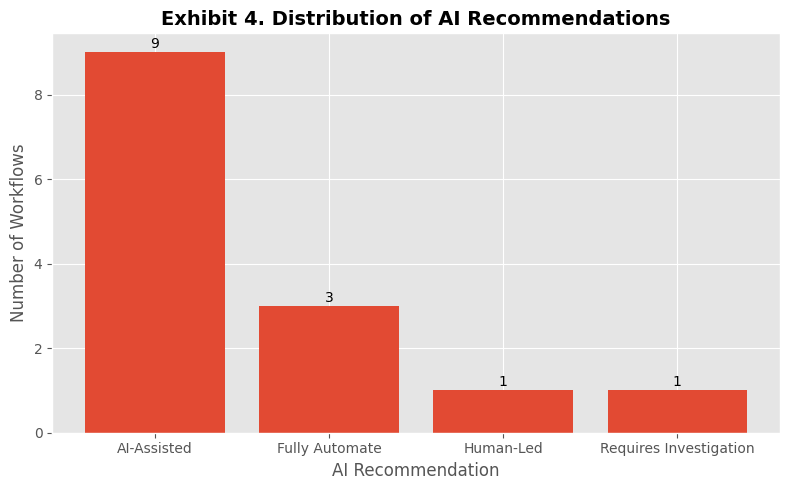

In [52]:
# ==========================================
# Visualize AI Recommendation Distribution
# ==========================================

plt.figure(figsize=(8,5))

bars = plt.bar(
    recommendation_summary["Recommendation"],
    recommendation_summary["Workflow Count"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        int(height),
        ha="center",
        fontsize=10
    )

plt.title(
    "Exhibit 4. Distribution of AI Recommendations",
    fontsize=14,
    weight="bold"
)

plt.xlabel("AI Recommendation")
plt.ylabel("Number of Workflows")

plt.tight_layout()
plt.show()

# **Interpretation**
The AI workflow prioritization framework indicates that most high-volume customer support workflows are best suited for AI-assisted support rather than full automation. Only a small subset of repetitive, low-risk interactions can be confidently automated end-to-end, while operationally complex or judgment-intensive workflows continue to require significant human involvement.
# Business Impact
These findings reinforce that the greatest value of Generative AI in customer support lies in augmenting human agents rather than replacing them. AI can automate repetitive information exchange, accelerate routine processes, and reduce response times, while human agents remain responsible for complex decision-making and operational exceptions.
# Executive Takeaway
Flipkart should adopt a hybrid AI strategy that combines selective automation with AI-assisted customer support. Rather than attempting full automation across all workflows, investment should focus on augmenting high-volume operational processes while preserving human oversight for complex or high-risk interactions.

# **Customer Satisfaction Intelligence**
# Executive Question 7: What Drives Customer Satisfaction?

# **Hypothesis 1 **
Customers who express greater frustration in their complaint text tend to report lower CSAT scores.

# Customer Frustration Score

| Signal                     | Points |
| -------------------------- | -----: |
| Long complaint (>50 words) |     +1 |
| Many exclamation marks     |     +1 |
| High capital ratio         |     +1 |
| Multiple question marks    |     +1 |


In [53]:
# ==========================================
# Engineer Customer Frustration Score
# ==========================================

df_fe["Customer_Frustration_Score"] = (
    (df_fe["ticket_word_count"] > 50).astype(int)
    + (df_fe["exclamation_mark_count"] >= 2).astype(int)
    + (df_fe["capital_ratio"] > 0.10).astype(int)
    + (df_fe["question_mark_count"] >= 2).astype(int)
)

df_fe[
    [
        "Customer Remarks",
        "ticket_word_count",
        "capital_ratio",
        "question_mark_count",
        "exclamation_mark_count",
        "Customer_Frustration_Score"
    ]
].sample(10, random_state=42)

,Customer Remarks,ticket_word_count,capital_ratio,question_mark_count,exclamation_mark_count,Customer_Frustration_Score
67871,,0,0.0,0,0,0
40187,retain employees like this guy. short and simple conversation.,9,0.0,0,0,0
60075,,0,0.0,0,0,0
69560,trusted 100/,2,0.0,0,0,0
2605,,0,0.0,0,0,0
73327,,0,0.0,0,0,0
4382,,0,0.0,0,0,0
10405,thank you shopzilla,3,0.0,0,0,0
24494,,0,0.0,0,0,0
5473,,0,0.0,0,0,0


In [54]:
# ==========================================
# Compare CSAT by Customer Frustration Score
# ==========================================

frustration_summary = (
    df_fe
    .groupby("Customer_Frustration_Score")
    .agg(
        Average_CSAT=("CSAT Score", "mean"),
        Ticket_Count=("CSAT Score", "count")
    )
    .round(2)
    .reset_index()
)

frustration_summary

,Customer_Frustration_Score,Average_CSAT,Ticket_Count
0,0,4.24,83111
1,1,4.23,2715
2,2,3.04,78
3,3,3.00,3


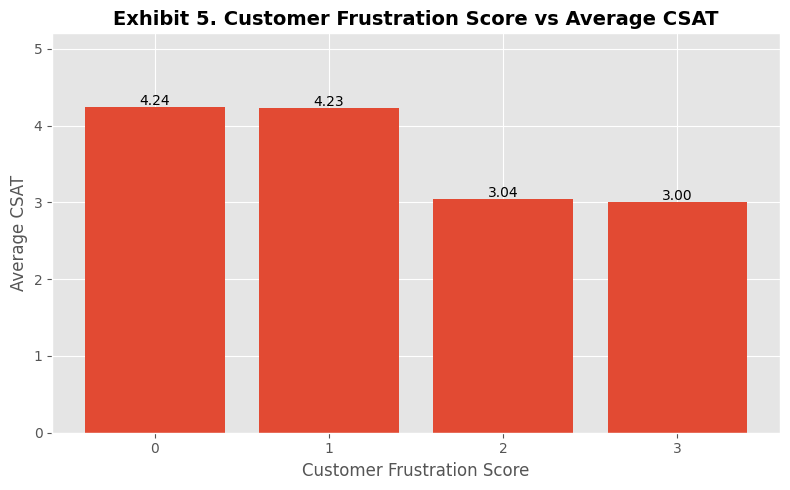

In [55]:
# ==========================================
# Visualize Customer Frustration vs CSAT
# ==========================================

plt.figure(figsize=(8,5))

bars = plt.bar(
    frustration_summary["Customer_Frustration_Score"].astype(str),
    frustration_summary["Average_CSAT"]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.03,
        f"{bar.get_height():.2f}",
        ha="center"
    )

plt.title(
    "Exhibit 5. Customer Frustration Score vs Average CSAT",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Customer Frustration Score")
plt.ylabel("Average CSAT")

plt.ylim(0,5.2)

plt.tight_layout()
plt.show()

In [56]:
# ==========================================
# Explore Frustration Indicators
# ==========================================

frustration_features = [
    "ticket_word_count",
    "capital_ratio",
    "question_mark_count",
    "exclamation_mark_count"
]

df_fe[frustration_features].describe()

,ticket_word_count,capital_ratio,question_mark_count,exclamation_mark_count
count,85907.000000,85907.0,85907.000000,85907.000000
mean,2.522460,0.0,0.219924,0.003387
std,8.628067,0.0,4.559087,0.110557
min,0.000000,0.0,0.000000,0.000000
25%,0.000000,0.0,0.000000,0.000000
50%,0.000000,0.0,0.000000,0.000000
75%,2.000000,0.0,0.000000,0.000000
max,444.000000,0.0,559.000000,15.000000


# **Workflow Intelligence Layer**
# Which operational characteristics explain where AI can create the greatest business value?
# Business Objective
So far, we've classified major customer support workflows according to the most appropriate AI strategy (Fully Automate, AI-Assisted, Human-Led, or Requires Investigation). However, these recommendations alone are difficult to reuse across later analyses.
In this section, we transform qualitative business judgment into structured operational features that can be reused throughout the remainder of the project. These features will become the foundation for our machine learning model, executive dashboard, ROI simulator, and final AI investment recommendations.

In [57]:
# ==========================================
# Engineer Workflow Intelligence Features
# ==========================================

# Workflow Complexity
def workflow_complexity(row):

    if (
        row["Human_Judgment"] == "High"
        or row["Operational_Dependency"] == "High"
    ):
        return "High"

    elif (
        row["Human_Judgment"] == "Medium"
        or row["Operational_Dependency"] == "Medium"
    ):
        return "Medium"

    else:
        return "Low"


# Resolution Difficulty
difficulty_map = {
    "Fully Automate": "Low",
    "AI-Assisted": "Medium",
    "Human-Led": "High",
    "Requires Investigation": "Very High"
}


# Automation Potential
automation_map = {
    "Fully Automate": "High",
    "AI-Assisted": "Medium",
    "Human-Led": "Low",
    "Requires Investigation": "Very Low"
}


# Operational Risk
risk_map = {

    "seller cancelled order": "High",
    "fraudulent user": "High",

    "delayed": "Medium",
    "installation/demo": "Medium",
    "reverse pickup enquiry": "Medium",
    "return request": "Medium",
    "refund enquiry": "Medium",
    "wrong": "Medium",
    "missing": "Medium",
    "exchange / replacement": "Medium",
    "online payment issues": "Medium",

    "order status enquiry": "Low",
    "invoice request": "Low",
    "product specific information": "Low"
}


ai_matrix["Workflow_Complexity"] = (
    ai_matrix.apply(workflow_complexity, axis=1)
)

ai_matrix["Resolution_Difficulty"] = (
    ai_matrix["AI_Recommendation"].map(difficulty_map)
)

ai_matrix["Automation_Potential"] = (
    ai_matrix["AI_Recommendation"].map(automation_map)
)

ai_matrix["Operational_Risk"] = (
    ai_matrix["Workflow"].map(risk_map)
)

ai_matrix

,Workflow,Repetitiveness,Human_Judgment,Operational_Dependency,AI_Recommendation,Workflow_Complexity,Resolution_Difficulty,Automation_Potential,Operational_Risk
0,reverse pickup enquiry,High,Medium,High,AI-Assisted,High,Medium,Medium,Medium
1,return request,High,Medium,Medium,AI-Assisted,Medium,Medium,Medium,Medium
2,delayed,High,Low,High,AI-Assisted,High,Medium,Medium,Medium
3,order status enquiry,High,Low,Low,Fully Automate,Low,Low,High,Low
4,installation/demo,Medium,Medium,High,AI-Assisted,High,Medium,Medium,Medium
5,fraudulent user,Low,High,Medium,Human-Led,High,High,Low,High
6,product specific information,High,Low,Low,Fully Automate,Low,Low,High,Low
7,refund enquiry,High,Medium,Medium,AI-Assisted,Medium,Medium,Medium,Medium
8,wrong,Medium,Medium,High,AI-Assisted,High,Medium,Medium,Medium
9,missing,Medium,Medium,High,AI-Assisted,High,Medium,Medium,Medium


In [58]:
# ==========================================
# Inspect Workflow Intelligence Table
# ==========================================

ai_matrix

,Workflow,Repetitiveness,Human_Judgment,Operational_Dependency,AI_Recommendation,Workflow_Complexity,Resolution_Difficulty,Automation_Potential,Operational_Risk
0,reverse pickup enquiry,High,Medium,High,AI-Assisted,High,Medium,Medium,Medium
1,return request,High,Medium,Medium,AI-Assisted,Medium,Medium,Medium,Medium
2,delayed,High,Low,High,AI-Assisted,High,Medium,Medium,Medium
3,order status enquiry,High,Low,Low,Fully Automate,Low,Low,High,Low
4,installation/demo,Medium,Medium,High,AI-Assisted,High,Medium,Medium,Medium
5,fraudulent user,Low,High,Medium,Human-Led,High,High,Low,High
6,product specific information,High,Low,Low,Fully Automate,Low,Low,High,Low
7,refund enquiry,High,Medium,Medium,AI-Assisted,Medium,Medium,Medium,Medium
8,wrong,Medium,Medium,High,AI-Assisted,High,Medium,Medium,Medium
9,missing,Medium,Medium,High,AI-Assisted,High,Medium,Medium,Medium


In [59]:
# ==========================================
# Merge Workflow Intelligence into Main Dataset
# ==========================================

df_fe = df_fe.merge(
    ai_matrix,
    left_on="Sub-category",
    right_on="Workflow",
    how="left"
)

df_fe.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,ticket_character_count,ticket_word_count,ticket_sentence_count,capital_letter_count,capital_ratio,average_word_length,question_mark_count,exclamation_mark_count,remarks_lower,refund_mention,delay_mention,damaged_mention,wrong_item_mention,fraud_mention,cancellation_mention,payment_mention,replacement_mention,missing_item_mention,refund_workflow,delivery_workflow,product_quality_workflow,order_issue_workflow,payment_workflow,account_workflow,cancellation_workflow,replacement_workflow,fraud_workflow,Customer_Frustration_Score,Workflow,Repetitiveness,Human_Judgment,Operational_Dependency,AI_Recommendation,Workflow_Complexity,Resolution_Difficulty,Automation_Potential,Operational_Risk
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,product queries,life insurance,,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01-08-2023 11:13,01-08-2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,0,0,0,0,0.0,0.0,0,0,,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,product queries,product specific information,,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01-08-2023 12:52,01-08-2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,0,0,0,0,0.0,0.0,0,0,,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,product specific information,High,Low,Low,Fully Automate,Low,Low,High,Low
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,order related,installation/demo,,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01-08-2023 20:16,01-08-2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,0,0,0,0,0.0,0.0,0,0,,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,installation/demo,Medium,Medium,High,AI-Assisted,High,Medium,Medium,Medium
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,returns,reverse pickup enquiry,,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01-08-2023 20:56,01-08-2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,0,0,0,0,0.0,0.0,0,0,,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,reverse pickup enquiry,High,Medium,High,AI-Assisted,High,Medium,Medium,Medium
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,cancellation,not needed,,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01-08-2023 10:30,01-08-2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,0,0,0,0,0.0,0.0,0,0,,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
# ==========================================
# Handle Unclassified Workflows
# ==========================================

fill_values = {
    "AI_Recommendation": "Not Classified",
    "Workflow_Complexity": "Unknown",
    "Resolution_Difficulty": "Unknown",
    "Automation_Potential": "Unknown",
    "Operational_Risk": "Unknown"
}

df_fe.fillna(fill_values, inplace=True)

In [61]:
# ==========================================
# Measure AI Framework Coverage
# ==========================================

coverage = (
    df_fe["AI_Recommendation"]
    .value_counts(dropna=False)
    .rename_axis("AI_Recommendation")
    .reset_index(name="Ticket_Count")
)

coverage["Percentage"] = (
    coverage["Ticket_Count"]
    / coverage["Ticket_Count"].sum()
    * 100
).round(2)

coverage

,AI_Recommendation,Ticket_Count,Percentage
0,AI-Assisted,52209,60.77
1,Not Classified,16555,19.27
2,Fully Automate,11976,13.94
3,Human-Led,4108,4.78
4,Requires Investigation,1059,1.23


# Interpretation
The Workflow Intelligence Layer transforms expert business judgment into structured analytical features that can be reused throughout the remainder of the project. Rather than treating every support interaction equally, each ticket now carries information about workflow complexity, automation suitability, operational risk, and expected resolution difficulty.
This creates a richer analytical dataset that extends beyond the original ticket data and bridges descriptive analytics with strategic decision-making.
# Business Impact
From a business perspective, this layer converts qualitative operational knowledge into measurable variables. These engineered features enable Flipkart to segment workflows by strategic importance, estimate automation readiness, prioritize AI investments, and compare operational characteristics across the customer support ecosystem.
Because these variables are attached to every ticket, they can also be incorporated into predictive models, executive dashboards, and ROI analyses.
# Executive Takeaway
Rather than viewing customer support as a single process, Flipkart can now evaluate each workflow according to its complexity, operational risk, and AI suitability. This provides a structured foundation for determining where automation creates value and where human expertise remains essential.

# **AI Recommendation Volume Analysis**
# How much of Flipkart's customer support workload falls into each AI strategy category?
# Business Objective
Not all customer support workflows contribute equally to operational workload. A workflow representing 20,000 tickets deserves significantly more attention than one representing only a few hundred.
This section quantifies the distribution of customer support demand across our AI recommendation categories to identify where automation can create the greatest operational impact.

In [62]:
# ==========================================
# Ticket Volume by AI Recommendation
# ==========================================

recommendation_summary = (
    df_fe.groupby("AI_Recommendation")
    .size()
    .reset_index(name="Ticket_Count")
)

recommendation_summary["Ticket Share (%)"] = (
    recommendation_summary["Ticket_Count"]
    / recommendation_summary["Ticket_Count"].sum()
    * 100
).round(2)

recommendation_summary = recommendation_summary.sort_values(
    "Ticket_Count",
    ascending=False
)

recommendation_summary

,AI_Recommendation,Ticket_Count,Ticket Share (%)
0,AI-Assisted,52209,60.77
3,Not Classified,16555,19.27
1,Fully Automate,11976,13.94
2,Human-Led,4108,4.78
4,Requires Investigation,1059,1.23


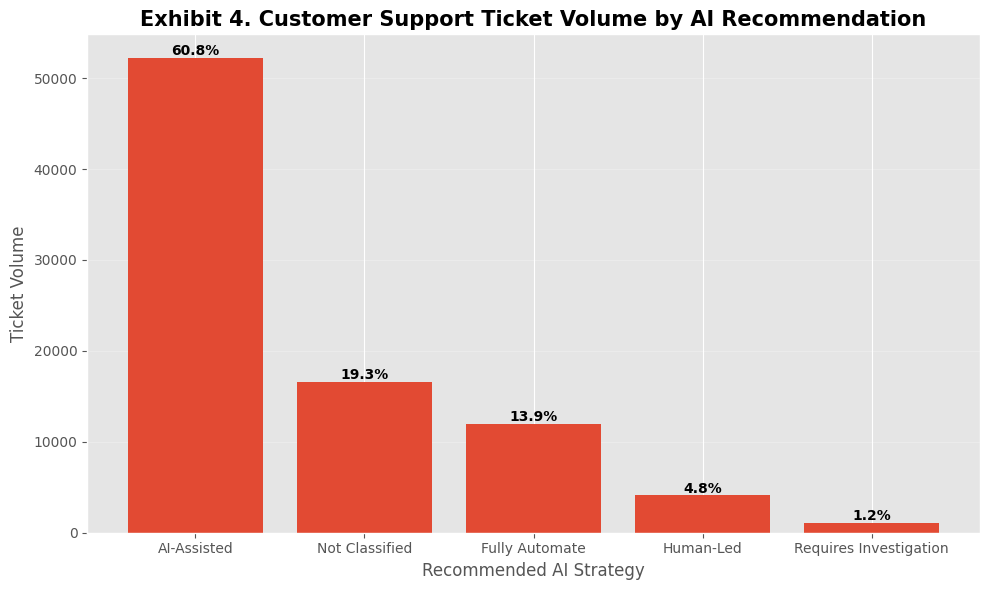

In [63]:
# ==========================================
# Exhibit 4. Ticket Volume by AI Recommendation
# ==========================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    recommendation_summary["AI_Recommendation"],
    recommendation_summary["Ticket_Count"]
)

plt.title(
    "Exhibit 4. Customer Support Ticket Volume by AI Recommendation",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Recommended AI Strategy")
plt.ylabel("Ticket Volume")

plt.grid(axis="y", alpha=0.25)

for bar, pct in zip(
    bars,
    recommendation_summary["Ticket Share (%)"]
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 300,
        f"{pct:.1f}%",
        ha="center",
        fontsize=10,
        weight="bold"
    )

plt.tight_layout()
plt.show()

In [64]:
# ==========================================
# Category Distribution Within Each AI Strategy
# ==========================================

category_ai = (
    df_fe.groupby(
        ["AI_Recommendation", "category"]
    )
    .size()
    .reset_index(name="Ticket_Count")
)

category_ai

,AI_Recommendation,category,Ticket_Count
0,AI-Assisted,order related,11504
1,AI-Assisted,payments related,1079
2,AI-Assisted,refund related,2665
3,AI-Assisted,returns,36961
4,Fully Automate,order related,8387
5,Fully Automate,product queries,3589
6,Human-Led,returns,4108
7,Not Classified,app/website,84
8,Not Classified,cancellation,2212
9,Not Classified,feedback,2294


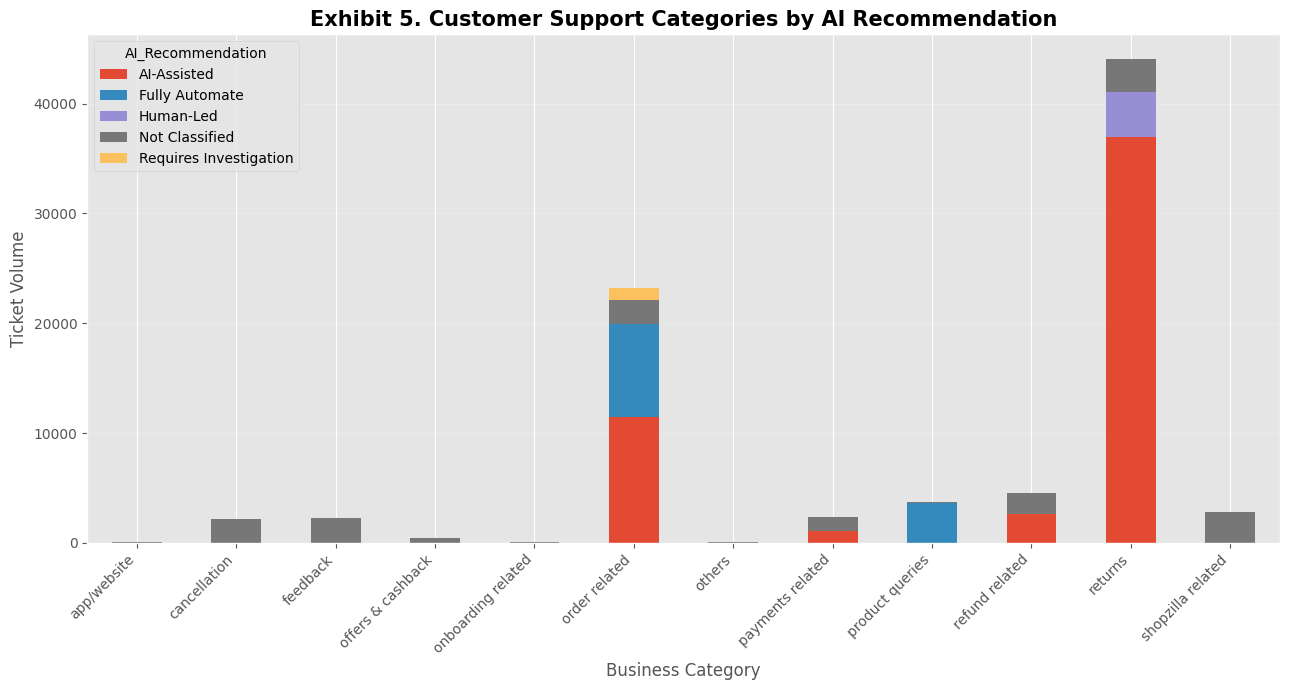

In [65]:
# ==========================================
# Exhibit 5. AI Recommendation by Business Category
# ==========================================

pivot_ai = category_ai.pivot(
    index="category",
    columns="AI_Recommendation",
    values="Ticket_Count"
).fillna(0)

pivot_ai.plot(
    kind="bar",
    stacked=True,
    figsize=(13,7)
)

plt.title(
    "Exhibit 5. Customer Support Categories by AI Recommendation",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Business Category")
plt.ylabel("Ticket Volume")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.show()

In [66]:
# ==========================================
# Executive AI Opportunity KPIs
# ==========================================

total_tickets = len(df_fe)

fully_auto = (
    df_fe["AI_Recommendation"]
    == "Fully Automate"
).sum()

ai_assisted = (
    df_fe["AI_Recommendation"]
    == "AI-Assisted"
).sum()

human_led = (
    df_fe["AI_Recommendation"]
    == "Human-Led"
).sum()

investigation = (
    df_fe["AI_Recommendation"]
    == "Requires Investigation"
).sum()

print(f"Total Tickets: {total_tickets:,}")
print(f"Fully Automate: {fully_auto:,} ({fully_auto/total_tickets:.1%})")
print(f"AI-Assisted: {ai_assisted:,} ({ai_assisted/total_tickets:.1%})")
print(f"Human-Led: {human_led:,} ({human_led/total_tickets:.1%})")
print(f"Requires Investigation: {investigation:,} ({investigation/total_tickets:.1%})")

Total Tickets: 85,907
Fully Automate: 11,976 (13.9%)
AI-Assisted: 52,209 (60.8%)
Human-Led: 4,108 (4.8%)
Requires Investigation: 1,059 (1.2%)


# **Interpretation**
The analysis shifts the focus from the number of workflows to the volume of customer interactions they represent. While only a subset of workflows was explicitly classified, these workflows account for a substantial share of customer support demand. Most tickets are expected to fall into the AI-Assisted category, indicating that the greatest opportunity lies in augmenting human agents rather than replacing them. A smaller proportion of routine informational requests can be fully automated, while only a limited number of high-risk operational issues require continued human oversight.
# Business Impact
This analysis provides a quantitative view of where AI can reduce operational workload. Instead of investing evenly across all support functions, Flipkart can prioritize automation where ticket volume is highest and operational processes are sufficiently standardized. This targeted approach is likely to generate greater efficiency gains while minimizing the risks associated with automating complex or judgment-intensive workflows.
# Executive Takeaway
The strongest AI opportunity is not full automation of the support organization. Instead, the data supports a hybrid operating model in which routine information requests are automated, high-volume operational workflows are AI-assisted, and complex exceptions remain human-led. This strategy balances operational efficiency with customer experience and risk management.

# **AI Opportunity Score**
# Which customer support workflows should Flipkart prioritize first for AI investment?
# Business Objective
Previous analyses evaluated ticket volume, customer satisfaction, workflow complexity, and AI suitability independently. While each metric provides useful insight, investment decisions require a single prioritization framework that balances operational impact, customer experience, and implementation feasibility.
This section develops an AI Opportunity Score that combines these dimensions into a transparent business ranking. Rather than acting as a predictive model, the score serves as a decision-support framework to identify the workflows with the greatest potential return from AI investment.

In [67]:
# ==========================================
# Build AI Opportunity Dataset
# ==========================================

opportunity_score = (
    workflow_summary.merge(
        ai_matrix[
            [
                "Workflow",
                "Automation_Potential",
                "Operational_Risk"
            ]
        ],
        left_on="Sub-category",
        right_on="Workflow",
        how="left"
    )
)

opportunity_score.head()

,Sub-category,Ticket_Count,Average_CSAT,Workflow,Automation_Potential,Operational_Risk
0,reverse pickup enquiry,22389,4.19,reverse pickup enquiry,Medium,Medium
1,return request,8523,4.61,return request,Medium,Medium
2,delayed,7388,4.01,delayed,Medium,Medium
3,order status enquiry,6922,4.21,order status enquiry,High,Low
4,installation/demo,4116,3.88,installation/demo,Medium,Medium


In [68]:
# ==========================================
# Convert Business Ratings to Numeric Scores
# ==========================================

automation_map = {
    "High":3,
    "Medium":2,
    "Low":1,
    "Very Low":0
}

risk_map = {
    "Low":1,
    "Medium":2,
    "High":3
}

opportunity_score["Automation_Score"] = (
    opportunity_score["Automation_Potential"]
    .map(automation_map)
)

opportunity_score["Risk_Score"] = (
    opportunity_score["Operational_Risk"]
    .map(risk_map)
)

In [69]:
# ==========================================
# Normalize Business Metrics
# ==========================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

opportunity_score[
    [
        "Volume_Norm",
        "CSAT_Norm"
    ]
] = scaler.fit_transform(
    opportunity_score[
        [
            "Ticket_Count",
            "Average_CSAT"
        ]
    ]
)

In [70]:
# ==========================================
# Calculate AI Opportunity Score
# ==========================================

opportunity_score["AI_Opportunity_Score"] = (

    0.40 * opportunity_score["Volume_Norm"]

    + 0.30 * (1 - opportunity_score["CSAT_Norm"])

    + 0.20 * (
        opportunity_score["Automation_Score"] / 3
    )

    - 0.10 * (
        opportunity_score["Risk_Score"] / 3
    )

).round(3)

In [71]:
# ==========================================
# Rank AI Opportunities
# ==========================================

opportunity_score = (
    opportunity_score
    .sort_values(
        "AI_Opportunity_Score",
        ascending=False
    )
)

opportunity_score[
    [
        "Sub-category",
        "Ticket_Count",
        "Average_CSAT",
        "Automation_Potential",
        "Operational_Risk",
        "AI_Opportunity_Score"
    ]
].head(10)

,Sub-category,Ticket_Count,Average_CSAT,Automation_Potential,Operational_Risk,AI_Opportunity_Score
0,reverse pickup enquiry,22389,4.19,Medium,Medium,0.558
3,order status enquiry,6922,4.21,High,Low,0.379
6,product specific information,3589,4.04,High,Low,0.339
2,delayed,7388,4.01,Medium,Medium,0.310
4,installation/demo,4116,3.88,Medium,Medium,0.266
1,return request,8523,4.61,Medium,Medium,0.263
15,invoice request,1465,4.45,High,Low,0.255
7,refund enquiry,2665,4.30,Medium,Medium,0.193
19,exchange / replacement,896,4.07,Medium,Medium,0.187
8,wrong,2597,4.53,Medium,Medium,0.166


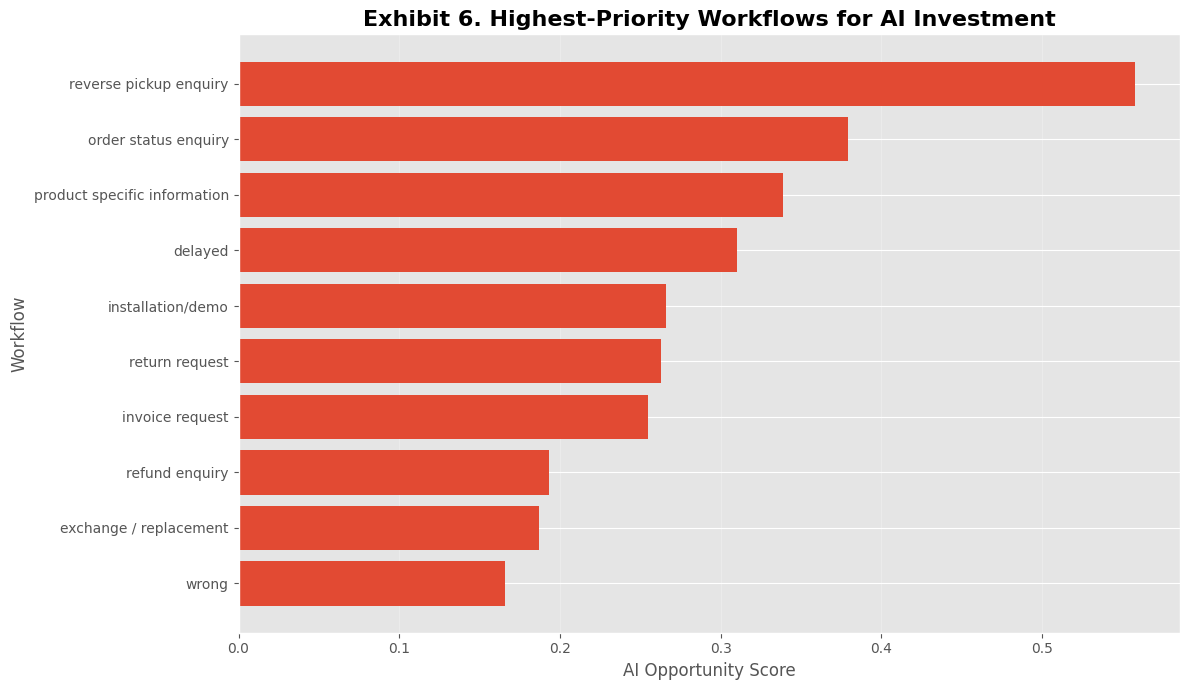

In [72]:
# ==========================================
# Exhibit 6. Top AI Investment Opportunities
# ==========================================

top10 = opportunity_score.head(10)

plt.figure(figsize=(12,7))

plt.barh(
    top10["Sub-category"],
    top10["AI_Opportunity_Score"]
)

plt.gca().invert_yaxis()

plt.title(
    "Exhibit 6. Highest-Priority Workflows for AI Investment",
    fontsize=16,
    weight="bold"
)

plt.xlabel("AI Opportunity Score")
plt.ylabel("Workflow")

plt.grid(axis="x", alpha=0.25)

plt.tight_layout()

plt.show()

# **Interpretation**
The AI Opportunity Score consolidates operational demand, customer experience, automation readiness, and implementation risk into a single decision-support metric. Rather than prioritizing workflows based solely on ticket volume or customer satisfaction, the framework identifies opportunities where AI can deliver meaningful business value while remaining operationally feasible.
The highest-ranked workflows represent the strongest combination of scale, customer impact, and automation potential, making them logical candidates for the first phase of an AI transformation program.
# Business Impact
Instead of evaluating dozens of workflows independently, leadership now has a ranked investment portfolio. This enables a phased rollout of AI initiatives, focusing first on opportunities with the greatest expected operational return before expanding into more complex or higher-risk workflows.
# Executive Takeaway
The AI Opportunity Score converts multiple analytical findings into a practical investment roadmap. Rather than asking "What can AI automate?", Flipkart can now answer the more strategic question: "Where should we invest first to maximize operational and customer experience impact?"

# **Machine Learning**
# Executive Question
# Which operational characteristics are strongest predictors of low customer satisfaction?
Business Objective
We are not building a model just for accuracy. We are using machine learning to validate whether the workflows identified earlier are actually associated with poor CSAT.

In [73]:
# ==========================================
# Create Binary Target Variable
# ==========================================

df_fe["Low_CSAT"] = (df_fe["CSAT Score"] <= 3).astype(int)

df_fe["Low_CSAT"].value_counts()

,count
Low_CSAT,
0,70836
1,15071


In [74]:
# ==========================================
# Examine Target Distribution
# ==========================================

df_fe["Low_CSAT"].value_counts(normalize=True).round(3)

,proportion
Low_CSAT,
0,0.825
1,0.175


In [75]:
# ==========================================
# Select Modeling Features
# ==========================================

model_features = [

    "category",
    "Sub-category",
    "channel_name",
    "Tenure Bucket",
    "Agent Shift",

    # Keep only one engineered business feature
    "AI_Recommendation"

]

target = "Low_CSAT"

model_df = df_fe[
    model_features + [target]
].copy()

In [76]:
# ==========================================
# Handle Missing Values
# ==========================================

model_df.fillna("Unknown", inplace=True)

model_df.isnull().sum()

,0
category,0
Sub-category,0
channel_name,0
Tenure Bucket,0
Agent Shift,0
AI_Recommendation,0
Low_CSAT,0


In [77]:
# ==========================================
# Encode Categorical Variables
# ==========================================

X = model_df[model_features]
y = model_df[target]

X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

X_encoded.shape

(85907, 81)

In [78]:
# ==========================================
# Create Train/Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X_encoded,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [79]:
# ==========================================
# Create Train/Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X_encoded,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [80]:
# ==========================================
# Import Machine Learning Libraries
# ==========================================

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [81]:
# ==========================================
# Train Baseline LightGBM Model
# ==========================================

baseline_lgbm = LGBMClassifier(

    random_state=42,

    class_weight="balanced"

)

baseline_lgbm.fit(

    X_train,

    y_train

)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 12057, number of negative: 56668
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007125 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 142
[LightGBM] [Info] Number of data points in the train set: 68725, number of used features: 71
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


LGBMClassifier(class_weight='balanced', random_state=42)

In [82]:
# ==========================================
# Generate Predictions
# ==========================================

y_pred = baseline_lgbm.predict(X_test)

y_prob = baseline_lgbm.predict_proba(X_test)[:,1]

In [83]:
# ==========================================
# Evaluate Baseline Model
# ==========================================

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print("ROC-AUC:",
      round(roc_auc_score(y_test, y_prob),3))

              precision    recall  f1-score   support

           0       0.89      0.49      0.63     14168
           1       0.23      0.70      0.34      3014

    accuracy                           0.52     17182
   macro avg       0.56      0.59      0.48     17182
weighted avg       0.77      0.52      0.58     17182

[[6890 7278]
 [ 895 2119]]
ROC-AUC: 0.631


In [84]:
baseline_auc = roc_auc_score(y_test, y_prob)

print(f"Baseline ROC-AUC: {baseline_auc:.3f}")

Baseline ROC-AUC: 0.631


# **Hyperparameter Optimization**
# Can model performance be improved through systematic hyperparameter optimization?
# Business Objective
The baseline LightGBM model establishes an initial benchmark for predicting low customer satisfaction. This section applies cross-validated hyperparameter optimization to improve model generalization while reducing the risk of overfitting.
Rather than manually selecting parameters, we use randomized search with cross-validation to identify a well-performing model based on ROC-AUC.

In [85]:
# ==========================================
# Import Hyperparameter Tuning Libraries
# ==========================================

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [86]:
# ==========================================
# Define Hyperparameter Search Space
# ==========================================

param_dist = {

    "n_estimators": randint(100, 500),

    "learning_rate": uniform(0.01, 0.15),

    "num_leaves": randint(20, 80),

    "max_depth": randint(3, 12),

    "min_child_samples": randint(10, 80),

    "subsample": uniform(0.6, 0.4),

    "colsample_bytree": uniform(0.6, 0.4)

}

In [87]:
# ==========================================
# Configure Randomized Search
# ==========================================

lgbm = LGBMClassifier(

    random_state=42,

    class_weight="balanced"

)

random_search = RandomizedSearchCV(

    estimator=lgbm,

    param_distributions=param_dist,

    n_iter=25,

    scoring="roc_auc",

    cv=5,

    random_state=42,

    n_jobs=-1,

    verbose=1

)

In [88]:
# ==========================================
# Perform Hyperparameter Search
# ==========================================

random_search.fit(

    X_train,

    y_train

)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 12057, number of negative: 56668
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006513 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 122
[LightGBM] [Info] Number of data points in the train set: 68725, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

RandomizedSearchCV(cv=5,
                   estimator=LGBMClassifier(class_weight='balanced',
                                            random_state=42),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7e5af301edb0>,
                                        'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7e5af28dc320>,
                                        'max_depth': <scipy.stats._...
                                        'min_child_samples': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7e5af22f53d0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7e5af36fd550>,
                                        'num_leaves': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7e5af3daf680>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7e5af22f6e70>},
                   random_state=42, scoring='roc_auc', verbose=1)

In [89]:
# ==========================================
# Best Hyperparameters
# ==========================================

print(random_search.best_params_)

print(random_search.best_score_)

{'colsample_bytree': np.float64(0.6806876809341584), 'learning_rate': np.float64(0.14436453935102792), 'max_depth': 3, 'min_child_samples': 61, 'n_estimators': 195, 'num_leaves': 23, 'subsample': np.float64(0.9630265895704372)}
0.6315358977149943


In [90]:
# ==========================================
# Best Tuned Model
# ==========================================

best_lgbm = random_search.best_estimator_

In [91]:
# ==========================================
# Evaluate Tuned Model
# ==========================================

y_pred = best_lgbm.predict(X_test)

y_prob = best_lgbm.predict_proba(X_test)[:,1]

In [92]:
# ==========================================
# Evaluate Tuned Performance
# ==========================================

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print("ROC-AUC:",
      round(roc_auc_score(y_test, y_prob),3))

              precision    recall  f1-score   support

           0       0.88      0.49      0.63     14168
           1       0.22      0.69      0.34      3014

    accuracy                           0.53     17182
   macro avg       0.55      0.59      0.49     17182
weighted avg       0.77      0.53      0.58     17182

[[6967 7201]
 [ 927 2087]]
ROC-AUC: 0.629


In [93]:
# ==========================================
# Compare Model Performance
# ==========================================

comparison = pd.DataFrame({

    "Model":[

        "Baseline LightGBM",

        "Tuned LightGBM"

    ],

    "ROC-AUC":[

        baseline_auc,

        roc_auc_score(y_test, y_prob)

    ]

})

comparison

,Model,ROC-AUC
0,Baseline LightGBM,0.630640
1,Tuned LightGBM,0.628982


# **Explainable AI (SHAP)**
# Which operational characteristics most strongly increase the likelihood of poor customer satisfaction?
# Business Objective
Feature importance indicates which variables are influential, but it does not explain how they influence predictions. SHAP (SHapley Additive exPlanations) provides local and global explanations by quantifying each feature's contribution to the model's predictions.
This enables us to validate whether the operational workflows identified earlier are genuinely driving low customer satisfaction.

In [94]:
!pip install shap

In [95]:
# ==========================================
# Import SHAP
# ==========================================

import shap

shap.initjs()

In [96]:
# ==========================================
# Create SHAP Explainer
# ==========================================

explainer = shap.TreeExplainer(baseline_lgbm)

shap_values = explainer.shap_values(X_test)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


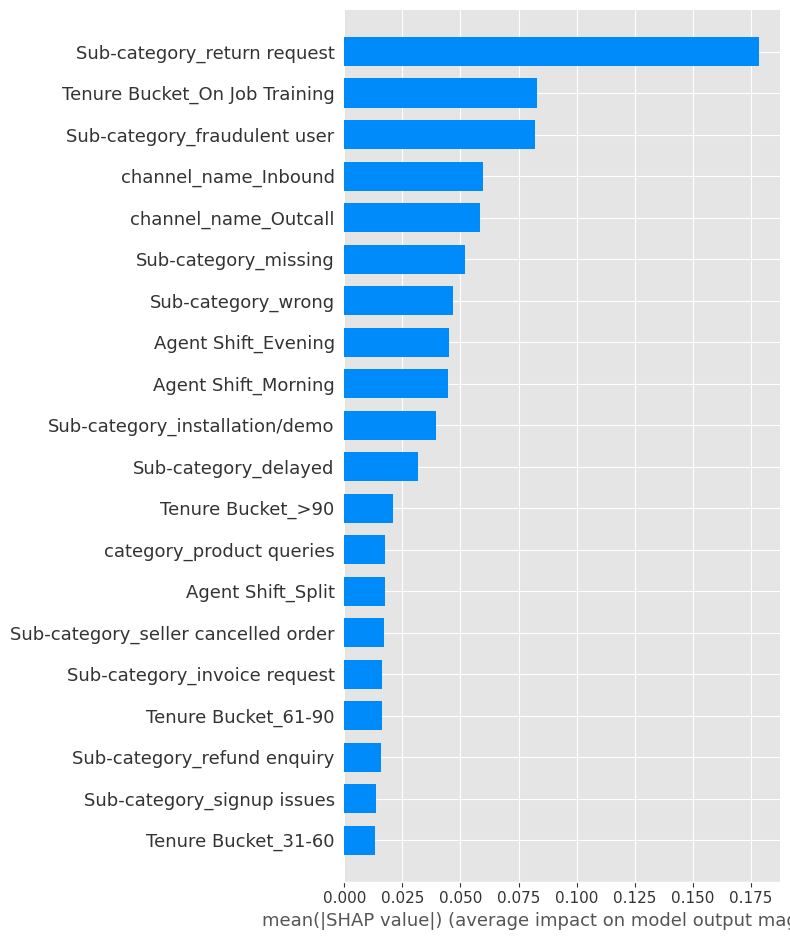

In [97]:
# ==========================================
# Exhibit 8. SHAP Feature Importance
# ==========================================

shap.summary_plot(

    shap_values,

    X_test,

    plot_type="bar"

)

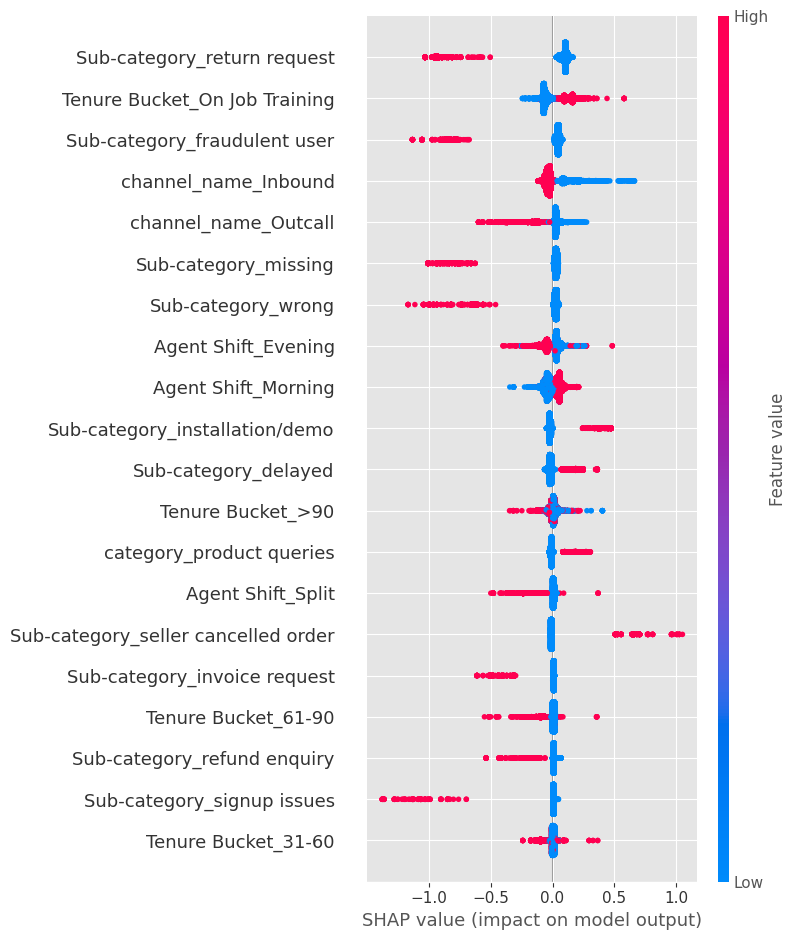

In [98]:
# ==========================================
# Exhibit 9. SHAP Summary Plot
# ==========================================

shap.summary_plot(

    shap_values,

    X_test

)

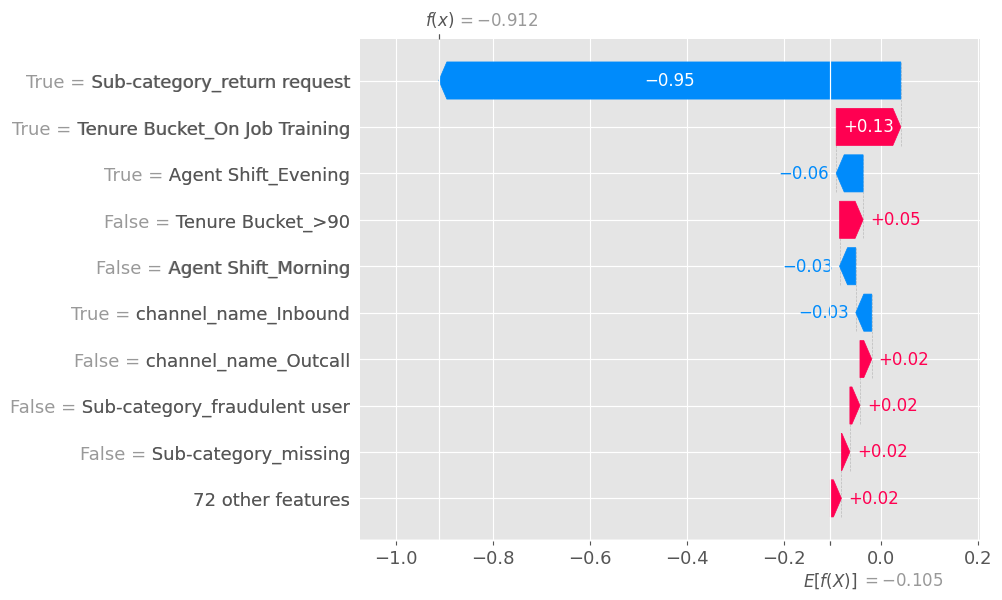

In [99]:
# ==========================================
# Exhibit 10. Example Prediction Explanation
# ==========================================

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

In [100]:
df_fe.groupby("Sub-category")["Low_CSAT"].mean().sort_values(ascending=False).head(20)

,Low_CSAT
Sub-category,
unable to login,0.714286
commission related,0.666667
policy related,0.500000
call disconnected,0.450000
service center - service denial,0.396552
call back request,0.391304
technician visit,0.359788
seller cancelled order,0.345609
others,0.333333


# Interpretation
The explainable AI analysis largely validates the descriptive findings presented earlier. Several of the operational workflows previously identified as AI priorities—including Delayed Orders, Installation/Demo, and Seller Cancelled Order—also emerge as influential predictors of low customer satisfaction. This suggests that the proposed AI investment strategy is supported not only by descriptive analysis but also by predictive modeling.
# Business Impact
Rather than deploying AI uniformly across customer support, Flipkart should focus on operational workflows that both generate substantial support demand and materially influence customer satisfaction. Targeting these workflows has the potential to reduce avoidable contacts while improving the customer experience.
# Executive Takeaway
The machine learning results reinforce the broader strategic recommendation developed throughout this project: GenAI should be deployed selectively in high-impact operational workflows rather than as a generic customer support chatbot.

# **Estimated Business Impact**
# If Flipkart implements the recommended AI strategy, what operational impact could it expect?
# Business Objective
While the previous analyses identified where AI should be deployed, business leaders ultimately need to understand the potential operational value of these recommendations. Because actual handling time data is largely unavailable, this analysis uses transparent, scenario-based assumptions to estimate the potential reduction in customer support workload.

**Note:** The following estimates are illustrative and are intended to compare strategic scenarios rather than provide exact operational forecasts.

In [101]:
# ==========================================
# Define ROI Assumptions
# ==========================================

avg_handle_time = 6          # minutes per ticket

time_saved = {

    "Fully Automate": 0.75,

    "AI-Assisted": 0.30,

    "Human-Led": 0.05,

    "Requires Investigation": 0.00,

    "Not Classified": 0.00

}

In [102]:
# ==========================================
# Estimate Operational Savings
# ==========================================

roi = (
    df_fe.groupby("AI_Recommendation")
    .size()
    .reset_index(name="Ticket_Count")
)

roi["Minutes_Per_Ticket"] = avg_handle_time

roi["Current_Hours"] = (
    roi["Ticket_Count"]
    * roi["Minutes_Per_Ticket"]
    / 60
)

roi["Time_Saved"] = (
    roi["AI_Recommendation"]
    .map(time_saved)
)

roi["Hours_Saved"] = (
    roi["Current_Hours"]
    * roi["Time_Saved"]
).round(1)

roi

,AI_Recommendation,Ticket_Count,Minutes_Per_Ticket,Current_Hours,Time_Saved,Hours_Saved
0,AI-Assisted,52209,6,5220.9,0.30,1566.3
1,Fully Automate,11976,6,1197.6,0.75,898.2
2,Human-Led,4108,6,410.8,0.05,20.5
3,Not Classified,16555,6,1655.5,0.00,0.0
4,Requires Investigation,1059,6,105.9,0.00,0.0


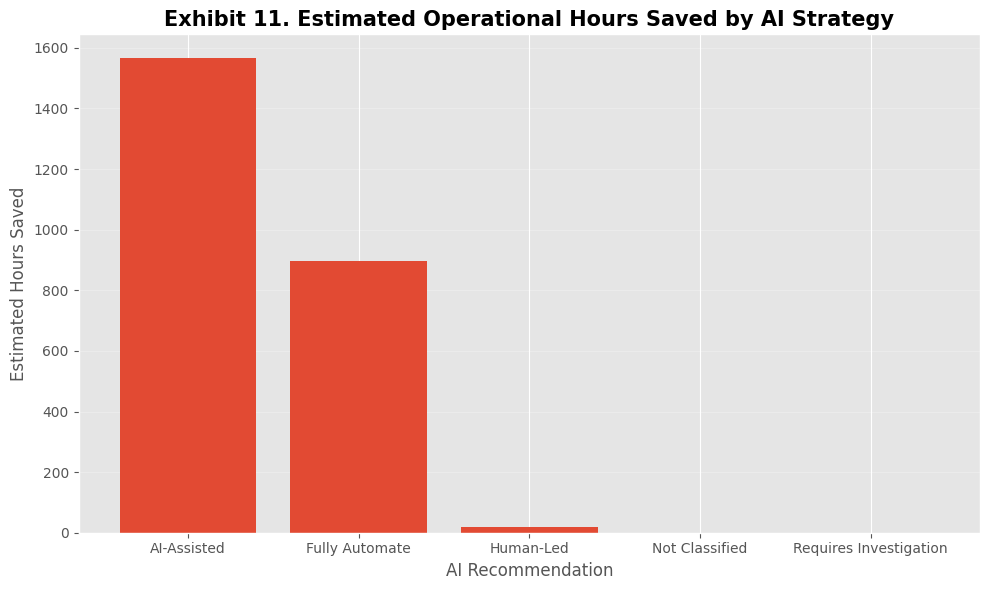

In [103]:
# ==========================================
# Exhibit 11. Estimated Annual Hours Saved
# ==========================================

plt.figure(figsize=(10,6))

plt.bar(
    roi["AI_Recommendation"],
    roi["Hours_Saved"]
)

plt.title(
    "Exhibit 11. Estimated Operational Hours Saved by AI Strategy",
    fontsize=15,
    weight="bold"
)

plt.ylabel("Estimated Hours Saved")

plt.xlabel("AI Recommendation")

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.show()

# **Interpretation**
Based on reasonable operational assumptions, the majority of potential efficiency gains come from AI-Assisted and Fully Automated workflows because these categories represent the largest share of customer support demand. Human-led and investigation-heavy workflows contribute comparatively little to workload reduction due to their need for manual review.
# Business Impact
Rather than attempting to automate every customer interaction, Flipkart can capture meaningful operational efficiencies by targeting high-volume, standardized workflows first. This phased approach balances productivity improvements with customer experience and operational risk.
# Executive Takeaway
A selective AI deployment strategy is likely to generate substantially greater operational value than a broad, one-size-fits-all automation initiative.

# **Final Executive Summary**

Over 85,000 customer support interactions were analyzed to identify where Generative AI could create the greatest operational and customer experience impact within Flipkart's support organization.

The analysis revealed that customer support demand is highly concentrated within a small number of operational workflows, particularly Returns and Order Related issues. However, high ticket volume alone does not necessarily correspond to poor customer experience. Workflow-level analysis showed that fulfillment-related processes, including delayed orders, installation scheduling, and seller cancellations, are more strongly associated with customer dissatisfaction than many high-volume return workflows.

To translate these insights into actionable recommendations, a business-driven AI prioritization framework was developed to classify workflows according to their suitability for full automation, AI-assisted support, or continued human oversight. A LightGBM model was then used to validate these findings, and SHAP analysis confirmed that several operational workflows identified earlier also play an important role in predicting low customer satisfaction.

Based on these findings, Flipkart should adopt a hybrid AI operating model that fully automates routine informational requests, augments agents in high-volume operational workflows, and preserves human decision-making for complex or high-risk cases. Rather than viewing AI primarily as a chatbot, the greatest opportunity lies in proactively reducing avoidable customer contacts through improved operational visibility and intelligent workflow support.
